In [2]:
print("Hello")

Hello


In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os
from scipy.signal import resample_poly

Trim data for XSens Sensors for all sessions

In [22]:
def trim_signal(df: pd.DataFrame, t_start: float, t_end: float) -> pd.DataFrame:
    mask = (df["Time_s"] >= t_start) & (df["Time_s"] <= t_end)
    return df.loc[mask].reset_index(drop=True)

def get_start_end_time(df: pd.DataFrame) -> tuple[float, float]:
    # find two values in which acc_mag is higest [1st and second peak ]
    # Since we want to find from start and finish of the signal, we can look only in 150 seconds from start and end time
    time_start = df["Time_s"].iloc[0]
    time_end = df["Time_s"].iloc[-1]
    highest_acc_mag = 0
    for i in range(9000):  # 9000 samples = 150 seconds at 60 Hz
        acc_mag = np.sqrt(df["Acc_X"].iloc[i]**2 + df["Acc_Y"].iloc[i]**2 + df["Acc_Z"].iloc[i]**2)
        if acc_mag > highest_acc_mag:
            highest_acc_mag = acc_mag
            time_start = df["Time_s"].iloc[i]

    highest_acc_mag = 0
    for i in range(len(df) - 9000, len(df)):
        acc_mag = np.sqrt(df["Acc_X"].iloc[i]**2 + df["Acc_Y"].iloc[i]**2 + df["Acc_Z"].iloc[i]**2)
        if acc_mag > highest_acc_mag:
            highest_acc_mag = acc_mag
            time_end = df["Time_s"].iloc[i]
    return time_start, time_end

def load_sensor_file(filepath: Path, fs: int = FS) -> pd.DataFrame:
    """Load one Xsens .txt export and add a Time_s column starting at 0."""
    df = pd.read_csv(filepath, comment="/", header=0)

    # Sanity check: packet counter should increment by 1 with no gaps.
    # Handle 16-bit rollover (65535 -> 0 gives -65535)
    pc_diffs = df["PacketCounter"].diff().dropna()
    
    pc_diffs = pc_diffs.apply(lambda x: x + 65536 if x < 0 else x).unique()

    if not (len(pc_diffs) == 1 and pc_diffs[0] == 1):
        print(f"   [!] {filepath.name}: dropped frames detected! Diff steps found: {pc_diffs}")

    df["Time_s"] = np.arange(len(df)) / fs

    timedeltas = pd.to_timedelta(df["Time_s"], unit="s")
    df["Timestamp"] = timedeltas.apply(
        lambda td: (pd.Timestamp(0) + td).strftime("%H:%M:%S.%f")[:-3]
    )
    return df

def get_trimmed_dir(Data_Dir, File_prefix, FS=60):  # FS is sampling rate

    # Sensor Device ID -> body part placement
    SENSOR_MAP = {}

    # %% [markdown]
    # ## Step 0 — Load a single sensor file and add timestamps
    #
    # The raw .txt has ~12 comment lines (starting with `//`) before the header row.
    # `comment='/'` tells pandas to drop any line starting with `/`, including those
    # comment lines, while keeping the real header row (which doesn't start with `/`).
    # Packet counters across all 6 sensors here are continuous (step of 1, no gaps,
    # no NaNs), so Time_s can simply be built from the row index at 60 Hz.


    for files in Data_Dir.glob("*.txt"):
        result = files.name.split("_")[-1].rsplit(".", 1)[0]
        SENSOR_MAP[result] = result

    # %% [markdown]
    # ## Load all  sensors into a dict keyed by body part

    # %%
    sensors = {}  # body_part -> DataFrame

    for device_id, body_part in SENSOR_MAP.items():
        fpath = Data_Dir / f"{File_prefix}{device_id}.txt"
        df = load_sensor_file(fpath)
        sensors[body_part] = df
        print(f"{body_part:12s} ({device_id}): {len(df)} rows, "
            f"{df['Time_s'].iloc[-1]:.2f}s, NaNs={df.isna().sum().sum()}")

    # Confirm all sensors have matching length / packet counter range (they should)
    lengths = {bp: len(df) for bp, df in sensors.items()}
    pc_ranges = {bp: (df["PacketCounter"].iloc[0], df["PacketCounter"].iloc[-1]) for bp, df in sensors.items()}
    print("\nRow counts match across sensors:", len(set(lengths.values())) == 1)
    print("PacketCounter ranges match across sensors:", len(set(pc_ranges.values())) == 1)


    # %% [markdown]
    # ## Sanity plot before trimming
    # Standing still -> low, flat gyroscope signal. Walking -> clear oscillation.
    # Use this plot to confirm/adjust TRIM_START_S / TRIM_END_S visually.

    TRIM_START_S, TRIM_END_S = get_start_end_time(sensors["10B41710"]) # right wrist sensor as all three of them used the same hand for trigger

    # %%
    ref = sensors["10B41710"] 
    acc_mag = np.sqrt(ref["Acc_X"]**2 + ref["Acc_Y"]**2 + ref["Acc_Z"]**2)

    plt.figure(figsize=(12, 4))
    plt.axvline(TRIM_START_S, color="green", linestyle="--", linewidth=0.5, label=f"trim start ({TRIM_START_S:.2f}s)")
    plt.axvline(TRIM_END_S, color="red", linestyle="--", linewidth=0.5, label=f"trim end ({TRIM_END_S:.2f}s)")
    plt.plot(ref["Time_s"], acc_mag, label="Acc magnitude right wrist")
    plt.xlabel("Time (s)")
    plt.ylabel("Accelerometer reading magnitude")
    plt.title("Sensor accelerometer - check trim start and end times")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # %% [markdown]
    # ## Step 1 — Eliminate initial & final standing
    # Keep only rows where TRIM_START_S <= Time_s <= TRIM_END_S, for every sensor.
    # Time_s is NOT reset to 0 here, so all sensors and later stages stay on the
    # same absolute time axis (useful for cross-checking against video/notes later).

    trimmed = {bp: trim_signal(df, TRIM_START_S, TRIM_END_S) for bp, df in sensors.items()}

    for bp, df in trimmed.items():
        print(f"{bp:12s}: {len(df)} rows kept, "
            f"{df['Time_s'].iloc[0]:.2f}s -> {df['Time_s'].iloc[-1]:.2f}s")

    ## Save trimmed data for the next pipeline stage (Turns Identification)

    OUT_DIR = Data_Dir / "trimmed"
    OUT_DIR.mkdir(exist_ok=True)

    for bp, df in trimmed.items():
        df.to_csv(OUT_DIR / f"trimmed_{bp}.csv", index=False)

    print(f"Saved {len(trimmed)} trimmed files to {OUT_DIR}")

Processing data in C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1
10B41704     (10B41704): 46738 rows, 778.95s, NaNs=0
10B41706     (10B41706): 46738 rows, 778.95s, NaNs=0
10B4170B     (10B4170B): 46738 rows, 778.95s, NaNs=0
   [!] XSensData_Rome_10B4170C.txt: dropped frames detected! Diff steps found: [1. 2.]
10B4170C     (10B4170C): 46737 rows, 778.93s, NaNs=0
10B4170D     (10B4170D): 46738 rows, 778.95s, NaNs=0
10B4170E     (10B4170E): 46738 rows, 778.95s, NaNs=0
   [!] XSensData_Rome_10B4170F.txt: dropped frames detected! Diff steps found: [1. 2.]
10B4170F     (10B4170F): 46737 rows, 778.93s, NaNs=0
10B41710     (10B41710): 46738 rows, 778.95s, NaNs=0
10B41721     (10B41721): 46738 rows, 778.95s, NaNs=0
10B41722     (10B41722): 46738 rows, 778.95s, NaNs=0
10B4175D     (10B4175D): 46738 rows, 778.95s, NaNs=0
10B4175E     (10B4175E): 46738 rows, 778.95s, NaNs=0
10B4175F     (10B4175F): 46738 rows, 778.95s, NaNs=0
10B41760     (10B41760): 46738 rows, 778.95

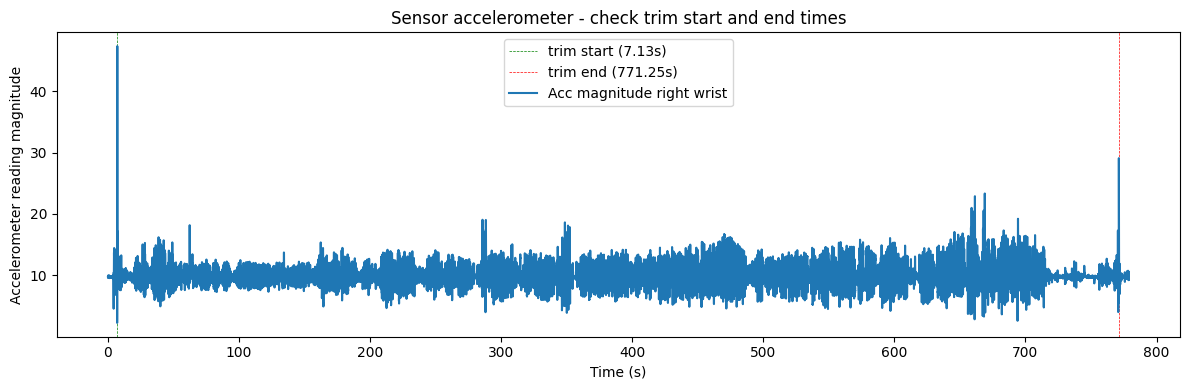

10B41704    : 45848 rows kept, 7.13s -> 771.25s
10B41706    : 45848 rows kept, 7.13s -> 771.25s
10B4170B    : 45848 rows kept, 7.13s -> 771.25s
10B4170C    : 45848 rows kept, 7.13s -> 771.25s
10B4170D    : 45848 rows kept, 7.13s -> 771.25s
10B4170E    : 45848 rows kept, 7.13s -> 771.25s
10B4170F    : 45848 rows kept, 7.13s -> 771.25s
10B41710    : 45848 rows kept, 7.13s -> 771.25s
10B41721    : 45848 rows kept, 7.13s -> 771.25s
10B41722    : 45848 rows kept, 7.13s -> 771.25s
10B4175D    : 45848 rows kept, 7.13s -> 771.25s
10B4175E    : 45848 rows kept, 7.13s -> 771.25s
10B4175F    : 45848 rows kept, 7.13s -> 771.25s
10B41760    : 45848 rows kept, 7.13s -> 771.25s
10B4178A    : 45848 rows kept, 7.13s -> 771.25s
10B417FF    : 45848 rows kept, 7.13s -> 771.25s
10B41825    : 45848 rows kept, 7.13s -> 771.25s
Saved 17 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\trimmed
Processing data in C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Sub

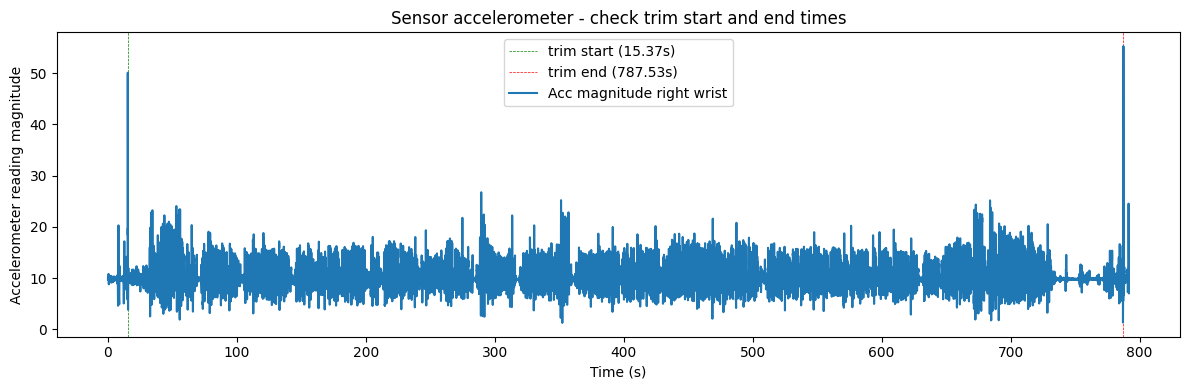

10B41704    : 46331 rows kept, 15.37s -> 787.53s
10B41706    : 46331 rows kept, 15.37s -> 787.53s
10B4170B    : 46331 rows kept, 15.37s -> 787.53s
10B4170C    : 46331 rows kept, 15.37s -> 787.53s
10B4170D    : 46331 rows kept, 15.37s -> 787.53s
10B4170E    : 46331 rows kept, 15.37s -> 787.53s
10B4170F    : 46331 rows kept, 15.37s -> 787.53s
10B41710    : 46331 rows kept, 15.37s -> 787.53s
10B41721    : 46331 rows kept, 15.37s -> 787.53s
10B41722    : 46331 rows kept, 15.37s -> 787.53s
10B4175D    : 46331 rows kept, 15.37s -> 787.53s
10B4175E    : 46331 rows kept, 15.37s -> 787.53s
10B4175F    : 46331 rows kept, 15.37s -> 787.53s
10B41760    : 46331 rows kept, 15.37s -> 787.53s
10B4178A    : 46331 rows kept, 15.37s -> 787.53s
10B417FF    : 46331 rows kept, 15.37s -> 787.53s
10B41825    : 46331 rows kept, 15.37s -> 787.53s
Saved 17 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_2\trimmed
Processing data in C:\Users\Vaibhav\Documents\Data_Collect

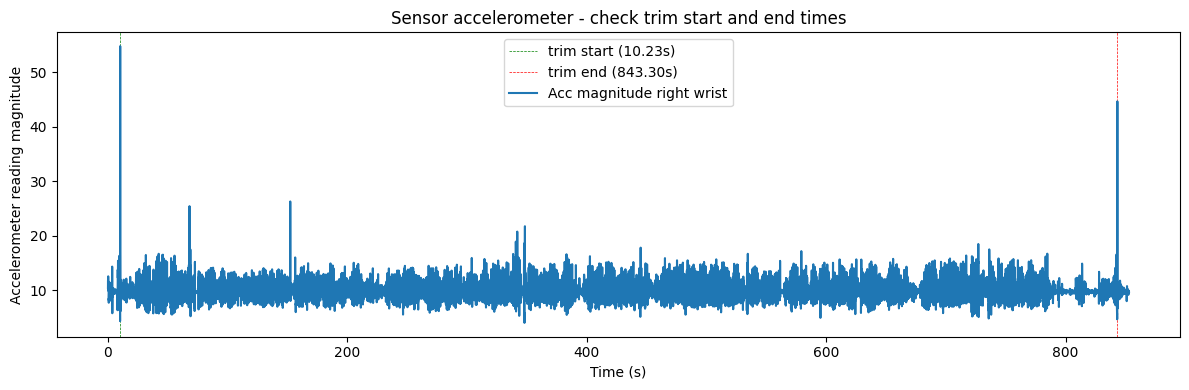

10B41704    : 49985 rows kept, 10.23s -> 843.30s
10B41706    : 49985 rows kept, 10.23s -> 843.30s
10B4170B    : 49985 rows kept, 10.23s -> 843.30s
10B4170C    : 49985 rows kept, 10.23s -> 843.30s
10B4170D    : 49985 rows kept, 10.23s -> 843.30s
10B4170E    : 49985 rows kept, 10.23s -> 843.30s
10B4170F    : 49985 rows kept, 10.23s -> 843.30s
10B41710    : 49985 rows kept, 10.23s -> 843.30s
10B41721    : 49985 rows kept, 10.23s -> 843.30s
10B41722    : 49985 rows kept, 10.23s -> 843.30s
10B4175D    : 49985 rows kept, 10.23s -> 843.30s
10B4175E    : 49985 rows kept, 10.23s -> 843.30s
10B4175F    : 49985 rows kept, 10.23s -> 843.30s
10B41760    : 49985 rows kept, 10.23s -> 843.30s
10B4178A    : 49985 rows kept, 10.23s -> 843.30s
10B417FF    : 49985 rows kept, 10.23s -> 843.30s
10B41825    : 49985 rows kept, 10.23s -> 843.30s
Saved 17 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_2_F\Session_1\trimmed
Processing data in C:\Users\Vaibhav\Documents\Data_Collect

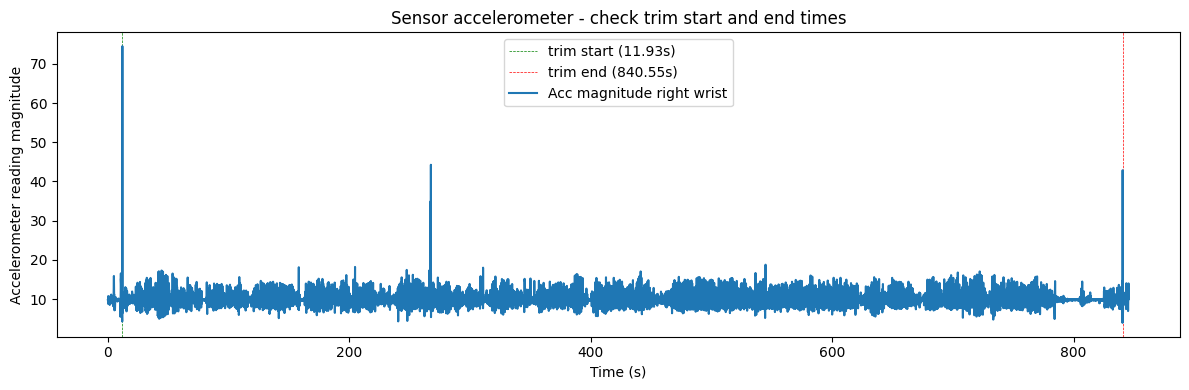

10B41704    : 49718 rows kept, 11.93s -> 840.55s
10B41706    : 49718 rows kept, 11.93s -> 840.55s
10B4170B    : 49718 rows kept, 11.93s -> 840.55s
10B4170C    : 49718 rows kept, 11.93s -> 840.55s
10B4170D    : 49718 rows kept, 11.93s -> 840.55s
10B4170E    : 49718 rows kept, 11.93s -> 840.55s
10B4170F    : 49718 rows kept, 11.93s -> 840.55s
10B41710    : 49718 rows kept, 11.93s -> 840.55s
10B41721    : 49718 rows kept, 11.93s -> 840.55s
10B41722    : 49718 rows kept, 11.93s -> 840.55s
10B4175D    : 49718 rows kept, 11.93s -> 840.55s
10B4175E    : 49718 rows kept, 11.93s -> 840.55s
10B4175F    : 49718 rows kept, 11.93s -> 840.55s
10B41760    : 49718 rows kept, 11.93s -> 840.55s
10B4178A    : 49718 rows kept, 11.93s -> 840.55s
10B417FF    : 49718 rows kept, 11.93s -> 840.55s
10B41825    : 49718 rows kept, 11.93s -> 840.55s
Saved 17 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_2_F\Session_2\trimmed
Processing data in C:\Users\Vaibhav\Documents\Data_Collect

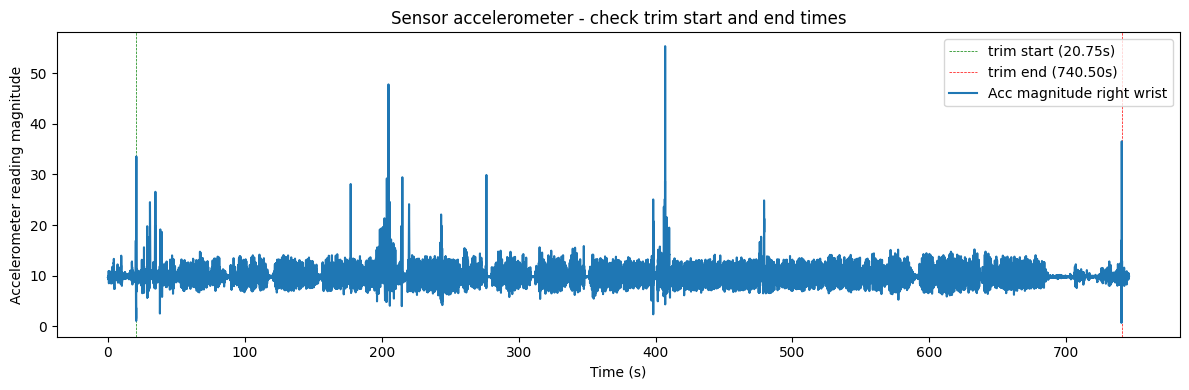

10B41704    : 43186 rows kept, 20.75s -> 740.50s
10B41706    : 43186 rows kept, 20.75s -> 740.50s
10B4170B    : 43186 rows kept, 20.75s -> 740.50s
10B4170C    : 43186 rows kept, 20.75s -> 740.50s
10B4170D    : 43186 rows kept, 20.75s -> 740.50s
10B4170E    : 43186 rows kept, 20.75s -> 740.50s
10B4170F    : 43186 rows kept, 20.75s -> 740.50s
10B41710    : 43186 rows kept, 20.75s -> 740.50s
10B41721    : 43186 rows kept, 20.75s -> 740.50s
10B41722    : 43186 rows kept, 20.75s -> 740.50s
10B4175D    : 43186 rows kept, 20.75s -> 740.50s
10B4175E    : 43186 rows kept, 20.75s -> 740.50s
10B4175F    : 43186 rows kept, 20.75s -> 740.50s
10B41760    : 43186 rows kept, 20.75s -> 740.50s
10B4178A    : 43186 rows kept, 20.75s -> 740.50s
10B417FF    : 43186 rows kept, 20.75s -> 740.50s
10B41825    : 43186 rows kept, 20.75s -> 740.50s
Saved 17 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_3_I\Session_1\trimmed
Processing data in C:\Users\Vaibhav\Documents\Data_Collect

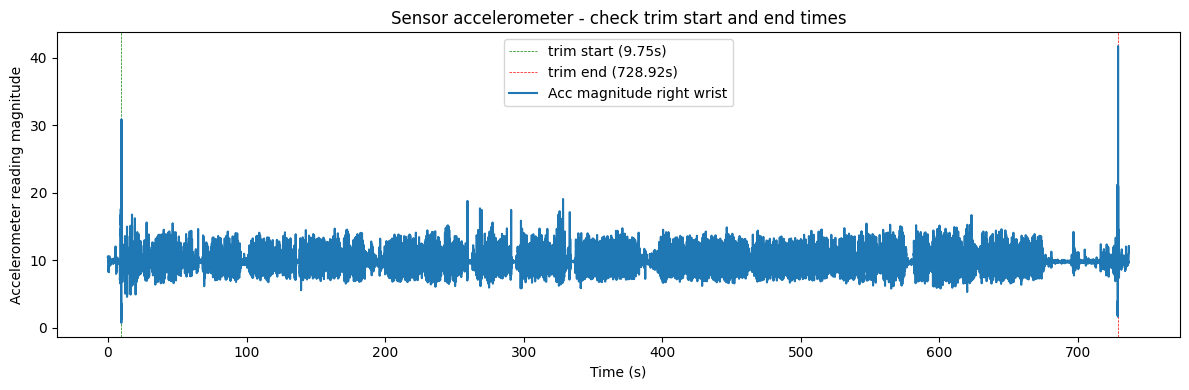

10B41704    : 43151 rows kept, 9.75s -> 728.92s
10B41706    : 43151 rows kept, 9.75s -> 728.92s
10B4170B    : 43151 rows kept, 9.75s -> 728.92s
10B4170C    : 43151 rows kept, 9.75s -> 728.92s
10B4170D    : 43151 rows kept, 9.75s -> 728.92s
10B4170E    : 43151 rows kept, 9.75s -> 728.92s
10B4170F    : 43151 rows kept, 9.75s -> 728.92s
10B41710    : 43151 rows kept, 9.75s -> 728.92s
10B41721    : 43151 rows kept, 9.75s -> 728.92s
10B41722    : 43151 rows kept, 9.75s -> 728.92s
10B4175D    : 43151 rows kept, 9.75s -> 728.92s
10B4175E    : 43151 rows kept, 9.75s -> 728.92s
10B4175F    : 43151 rows kept, 9.75s -> 728.92s
10B41760    : 43151 rows kept, 9.75s -> 728.92s
10B4178A    : 43151 rows kept, 9.75s -> 728.92s
10B417FF    : 43151 rows kept, 9.75s -> 728.92s
10B41825    : 43151 rows kept, 9.75s -> 728.92s
Saved 17 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_3_I\Session_2\trimmed


In [24]:
ses = ["Session_1", "Session_2"]
Data_Dir = Path(r"C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data")

def get_dir():
    folders = []
    for folder in Data_Dir.iterdir():
        folders.append(folder)
    return folders

for folder in get_dir():
    for session in ses:
        DATA_DIR = folder / session
        FILE_PREFIX = "XSensData_Rome" + "_"
        print(f"Processing data in {DATA_DIR}")
        get_trimmed_dir(DATA_DIR, FILE_PREFIX, FS=60)

Add the Step logger miliseconds in the data as another column in the trimmed data

In [16]:
Data_Dir = Path(r"C:\Users\Vaibhav\OneDrive - CNR\FILIPPO PALUMBO's files - IPIN2026\StepLogger")
session_files = ["20260903T103016_davide2", "20260903T104431_davide3", "20260903T111311_Filippo01", "20260903T113135_Filippo02", "20260903T120425_eqbal1", "20260903T122244_eqbal3"]
prefix_file = "buttonsPressed"

output_file = [os.path.join("Subject_1_D", "Session_1"), os.path.join("Subject_1_D", "Session_2"), os.path.join("Subject_2_F", "Session_1"), os.path.join("Subject_2_F", "Session_2"), os.path.join("Subject_3_I", "Session_1"), os.path.join("Subject_3_I", "Session_2")]
Data_Doc_Dir = Path(r"C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data")

for i in range(len(session_files)):
    file_path = os.path.join(Data_Dir, session_files[i],f"{prefix_file}.log")
    step_logger_df = pd.read_csv(file_path, delimiter = ":", header = None, names = ["time", "Checkpoint", "zeros_1", "zeros_2", "zeros_3"])
    step_logger_df["time_s"] = step_logger_df["time"] / 1000  # Convert milliseconds to seconds
    step_logger_df["time_s"] = (step_logger_df["time_s"] - step_logger_df["time_s"].iloc[0]).round(4)
    
    OUT_DIR = Path(os.path.join(Data_Doc_Dir, output_file[i], "step_logger"))
    OUT_DIR.mkdir(exist_ok=True)

    step_logger_df.to_csv(OUT_DIR / f"buttonsPressed.csv", index=False)

    print(f"Saved {len(step_logger_df)} rows to {OUT_DIR}")

Saved 84 rows to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\step_logger
Saved 84 rows to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_2\step_logger
Saved 84 rows to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_2_F\Session_1\step_logger
Saved 84 rows to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_2_F\Session_2\step_logger
Saved 84 rows to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_3_I\Session_1\step_logger
Saved 84 rows to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_3_I\Session_2\step_logger


Exploring the Step logger recordings

The length of the df 79046


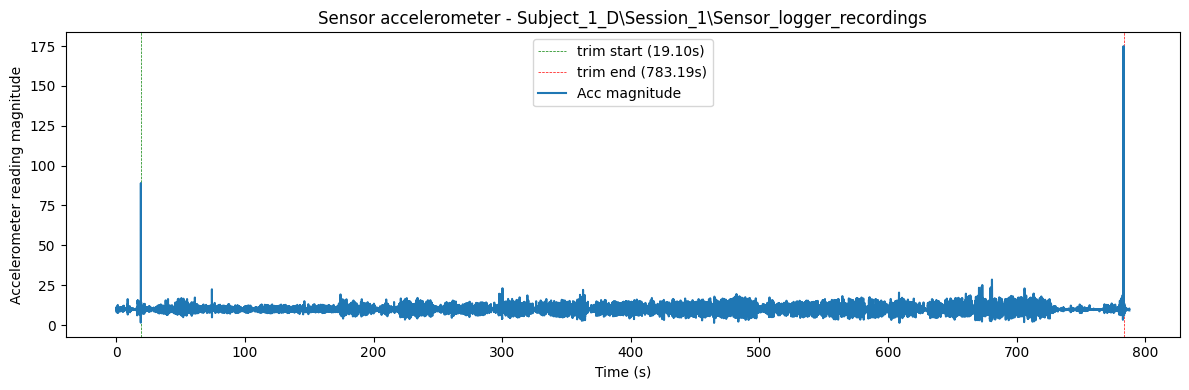

The length of the df 79310


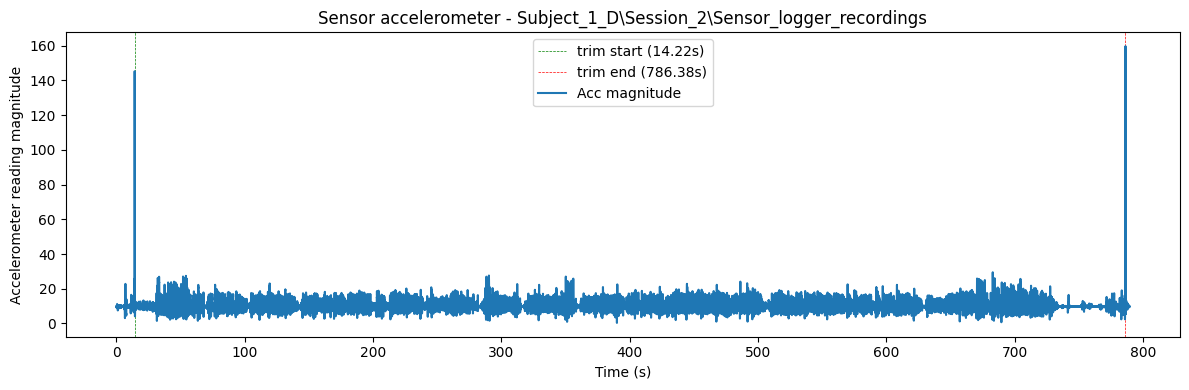

The length of the df 85625


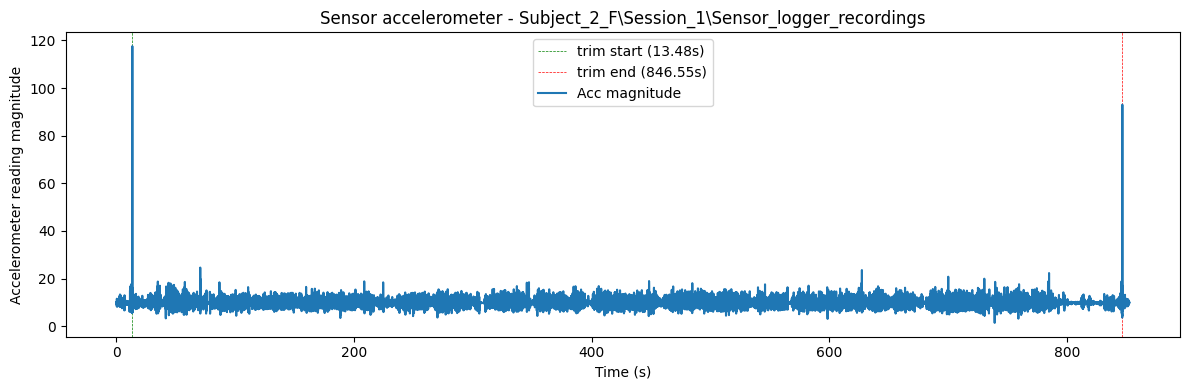

The length of the df 84703


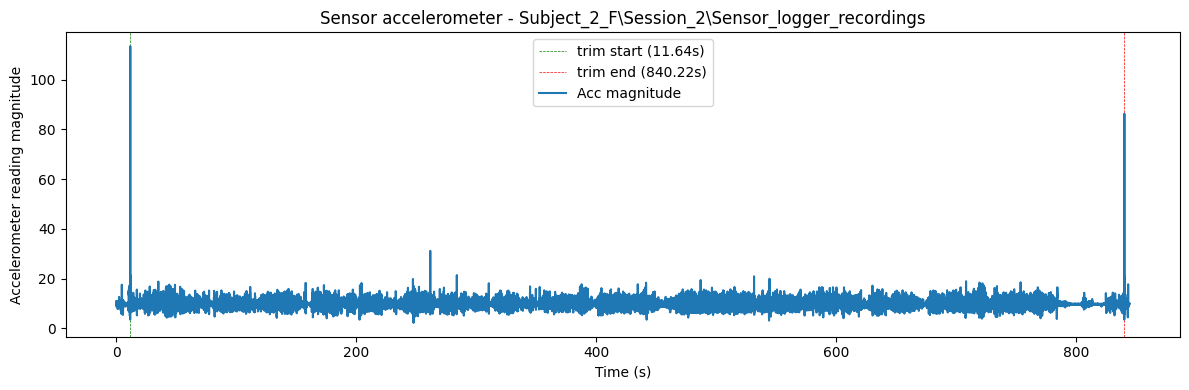

The length of the df 86530


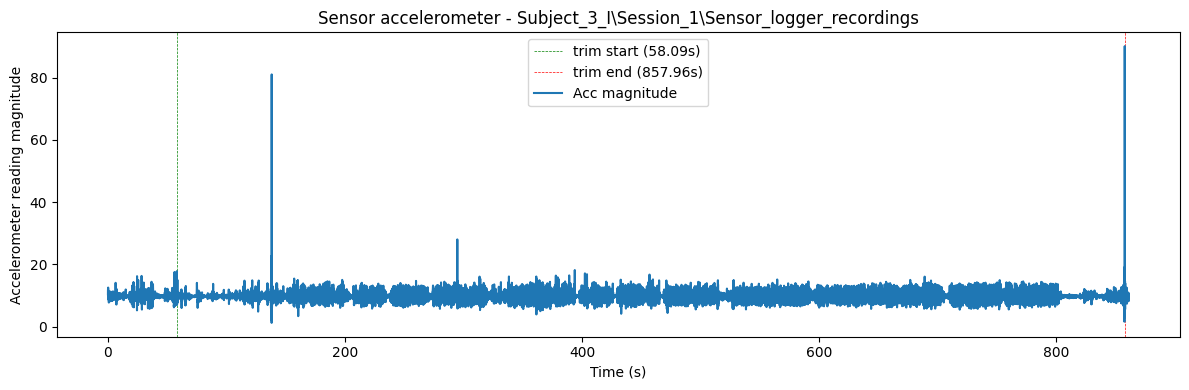

The length of the df 75668


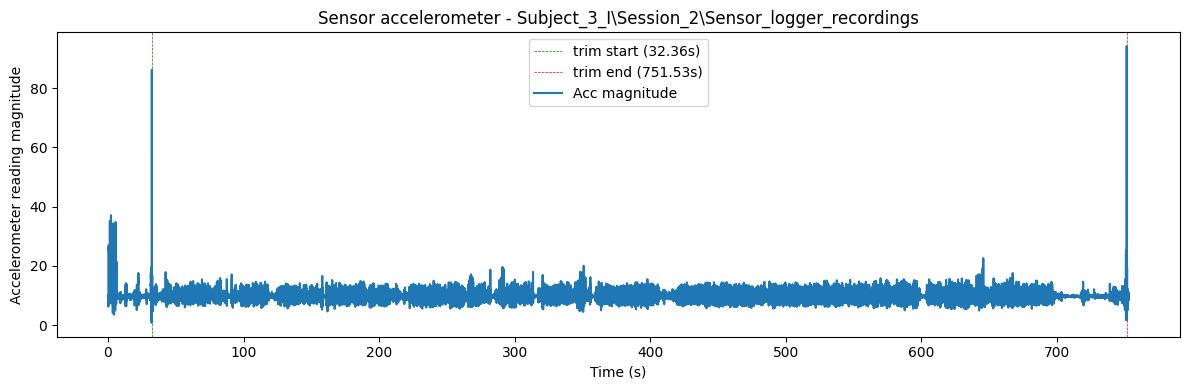

In [ ]:
dir_file = [os.path.join("Subject_1_D", "Session_1", "Sensor_logger_recordings"), os.path.join("Subject_1_D", "Session_2", "Sensor_logger_recordings"), os.path.join("Subject_2_F", "Session_1", "Sensor_logger_recordings"), os.path.join("Subject_2_F", "Session_2", "Sensor_logger_recordings"), os.path.join("Subject_3_I", "Session_1", "Sensor_logger_recordings"), os.path.join("Subject_3_I", "Session_2", "Sensor_logger_recordings")]
data_doc_dir = Path(r"C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data")
file_prefix = "TotalAcceleration.csv"

def trim_signal(df: pd.DataFrame, t_start: float, t_end: float) -> pd.DataFrame:
    mask = (df["Time_s"] >= t_start) & (df["Time_s"] <= t_end)
    return df.loc[mask].reset_index(drop=True)

def plot_acceleration_magnitude(dir_file, data_doc_dir, file_prefix):
    for i in range(len(dir_file)):
        
        file_path = os.path.join(data_doc_dir, dir_file[i], file_prefix)
        df = pd.read_csv(file_path, delimiter=',', header=0)
        print(f"The length of the df", len(df))
        df["time_s"] = df["time"] / 1e9
        df["time_s"] = (df["time_s"] - df["time_s"].iloc[0]).round(4)
        time_start, time_end = get_start_end_time(df)
        acc_mag = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)

        plt.figure(figsize=(12, 4))
        plt.ticklabel_format(useOffset=False, style="plain")
        plt.axvline(time_start, color="green", linestyle="--", linewidth=0.5, label=f"trim start ({time_start:.2f}s)")
        plt.axvline(time_end, color="red", linestyle="--", linewidth=0.5, label=f"trim end ({time_end:.2f}s)")
        plt.plot(df["time_s"], acc_mag, label="Acc magnitude")
        plt.xlabel("Time (s)")
        plt.ylabel("Accelerometer reading magnitude")
        plt.title(f"Sensor accelerometer - {dir_file[i]}")
        plt.legend()
        plt.tight_layout()
        plt.show()

def get_start_end_time(df: pd.DataFrame) -> tuple[float, float]:
    # find two values in which acc_mag is higest [1st and second peak ]
    # Since we want to find from start and finish of the signal, we can look only in 150 seconds from start and end time
    time_start = df["time_s"].iloc[0]
    time_end = df["time_s"].iloc[-1]
    highest_acc_mag = 0
    for i in range(10000):  # 10000 samples approx 120 seconds 
        acc_mag = np.sqrt(df["x"].iloc[i]**2 + df["y"].iloc[i]**2 + df["z"].iloc[i]**2)
        if acc_mag > highest_acc_mag:
            highest_acc_mag = acc_mag
            time_start = df["time_s"].iloc[i]

    highest_acc_mag = 0
    for i in range(len(df) - 10000, len(df)):
        acc_mag = np.sqrt(df["x"].iloc[i]**2 + df["y"].iloc[i]**2 + df["z"].iloc[i]**2)
        if acc_mag > highest_acc_mag:
            highest_acc_mag = acc_mag
            time_end = df["time_s"].iloc[i]
    return time_start, time_end

plot_acceleration_magnitude(dir_file, data_doc_dir, file_prefix)

Trimming files in the sensor logger and saving them in a folder

In [14]:
dir_file = [os.path.join("Subject_1_D", "Session_1", "Sensor_logger_recordings"), os.path.join("Subject_1_D", "Session_2", "Sensor_logger_recordings"), os.path.join("Subject_2_F", "Session_1", "Sensor_logger_recordings"), os.path.join("Subject_2_F", "Session_2", "Sensor_logger_recordings"), os.path.join("Subject_3_I", "Session_2", "Sensor_logger_recordings")]
data_doc_dir = Path(r"C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data")
prefix_file = "TotalAcceleration.csv"

def trim_signal(df: pd.DataFrame, t_start: float, t_end: float) -> pd.DataFrame:
    mask = (df["time_s"] >= t_start) & (df["time_s"] <= t_end)
    return df.loc[mask].reset_index(drop=True)

def get_start_end_time(df: pd.DataFrame) -> tuple[float, float]:
    # find two values in which acc_mag is higest [1st and second peak ]
    # Since we want to find from start and finish of the signal, we can look only in 150 seconds from start and end time
    time_start = df["time_s"].iloc[0]
    time_end = df["time_s"].iloc[-1]
    highest_acc_mag = 0
    for i in range(10000):  # 10000 samples approx 120 seconds 
        acc_mag = np.sqrt(df["x"].iloc[i]**2 + df["y"].iloc[i]**2 + df["z"].iloc[i]**2)
        if acc_mag > highest_acc_mag:
            highest_acc_mag = acc_mag
            time_start = df["time_s"].iloc[i]

    highest_acc_mag = 0
    for i in range(len(df) - 10000, len(df)):
        acc_mag = np.sqrt(df["x"].iloc[i]**2 + df["y"].iloc[i]**2 + df["z"].iloc[i]**2)
        if acc_mag > highest_acc_mag:
            highest_acc_mag = acc_mag
            time_end = df["time_s"].iloc[i]
    return time_start, time_end



for i in range(len(dir_file)):
        file_path = os.path.join(data_doc_dir, dir_file[i], file_prefix)
        df = pd.read_csv(file_path, delimiter=',', header=0)
        print(f"The length of the df", len(df))
        df["time_s"] = df["time"] / 1e9
        df["time_s"] = (df["time_s"] - df["time_s"].iloc[0]).round(4)
        time_start, time_end = get_start_end_time(df)

        for files in Path(os.path.join(data_doc_dir, dir_file[i])).glob("*.csv"):
            filename = files.stem.split("\\")[-1]

            if filename in ["Annotation", "Metadata"]:
                continue
            
            df = pd.read_csv(files, delimiter = ',', header = 0)
            df["time_s"] = df["time"] / 1e9
            df["time_s"] = (df["time_s"] - df["time_s"].iloc[0]).round(4)
            df = trim_signal(df, time_start, time_end)
            
            print(f"{len(df)} rows kept, "
            f"{df['time_s'].iloc[0]:.2f}s -> {df['time_s'].iloc[-1]:.2f}s")

            ## Save trimmed data for the next pipeline stage (Turns Identification)

            OUT_DIR = Path(os.path.join(data_doc_dir, dir_file[i], "trimmed"))
            OUT_DIR.mkdir(exist_ok=True)

            df.to_csv(OUT_DIR / f"trimmed_{filename}.csv", index=False)

            print(f"Saved {OUT_DIR / f"trimmed_{filename}.csv"} trimmed files to {OUT_DIR}")

print("Trimmed all the files and saved to the trimmed folder")
            
        

The length of the df 79046
38391 rows kept, 19.11s -> 783.18s
Saved C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\Sensor_logger_recordings\trimmed\trimmed_Accelerometer.csv trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\Sensor_logger_recordings\trimmed
76702 rows kept, 19.11s -> 783.19s
Saved C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\Sensor_logger_recordings\trimmed\trimmed_AccelerometerUncalibrated.csv trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\Sensor_logger_recordings\trimmed
30422 rows kept, 19.11s -> 783.18s
Saved C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\Sensor_logger_recordings\trimmed\trimmed_Barometer.csv trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\Sensor_logger_recordings\trimmed
76107 rows kept, 19.10s -> 783.19s
Saved C:\Users\Vaibhav\Documen

Mapping the checkpoints to both the wrist sensors and the android sensors using acceleration magnitude

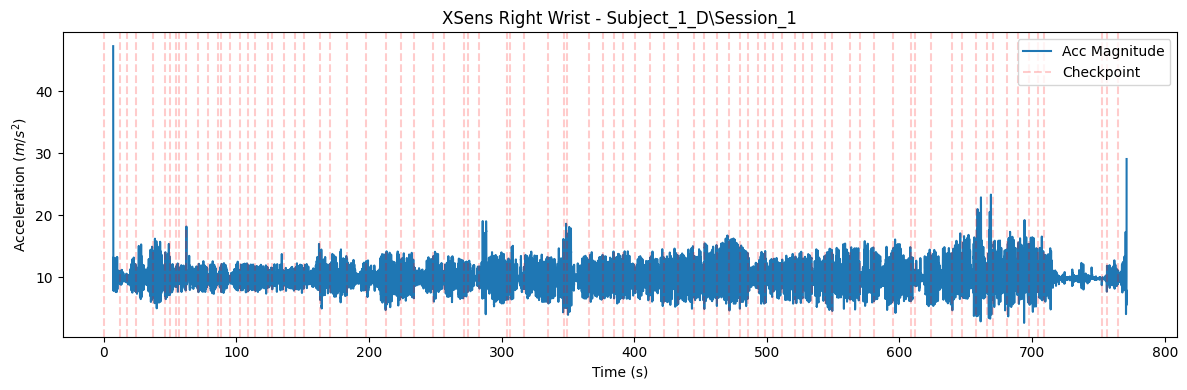

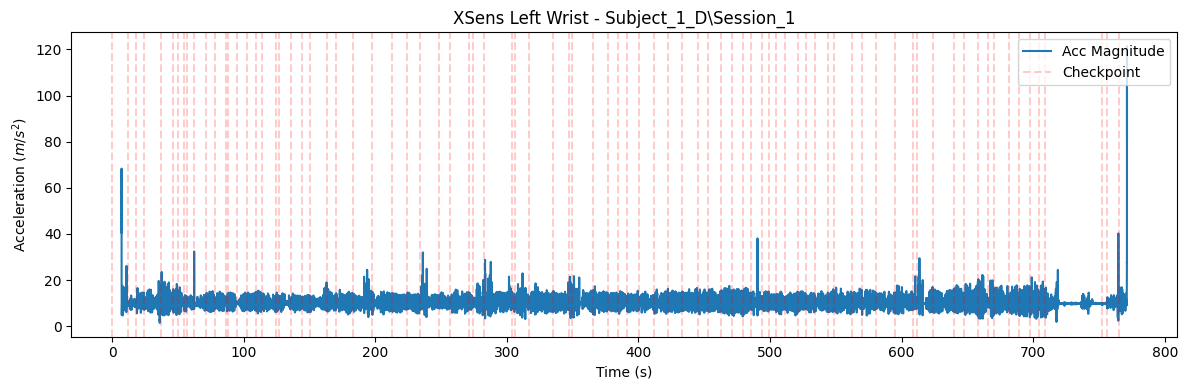

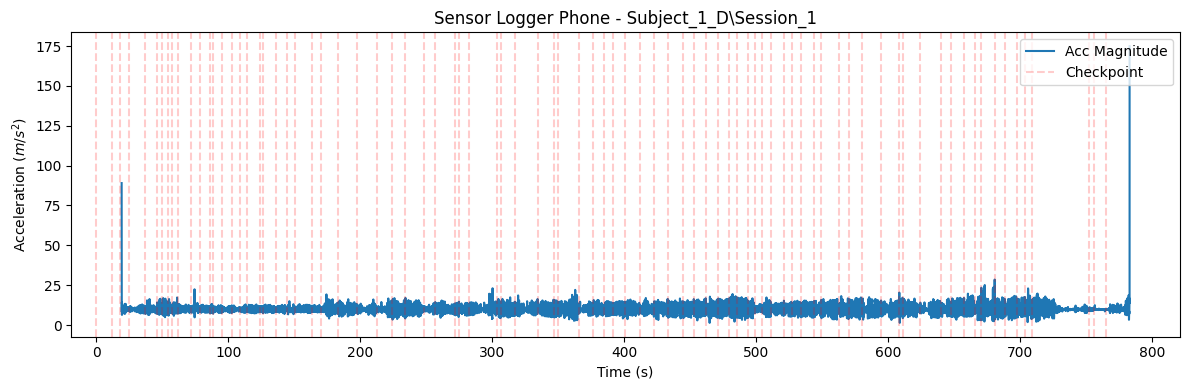

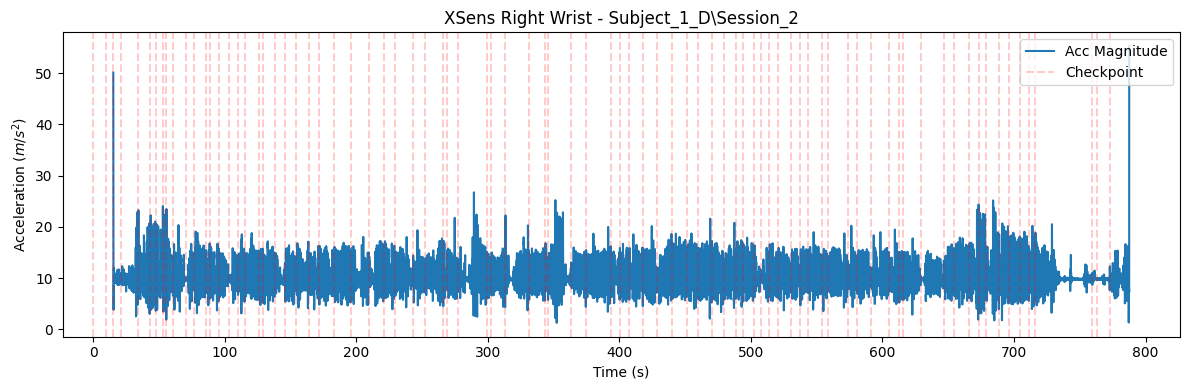

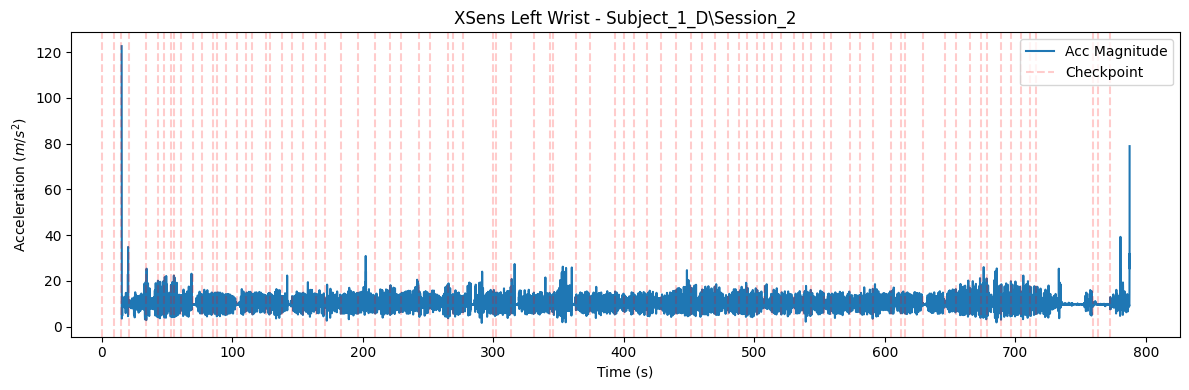

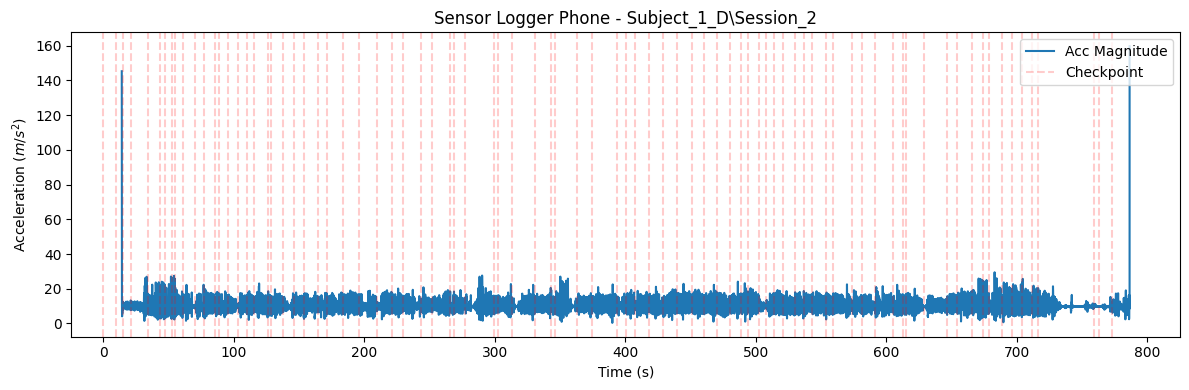

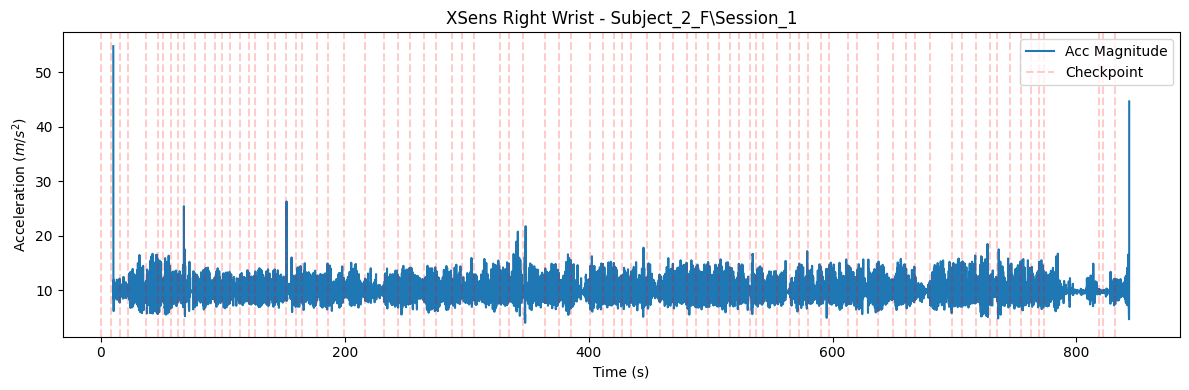

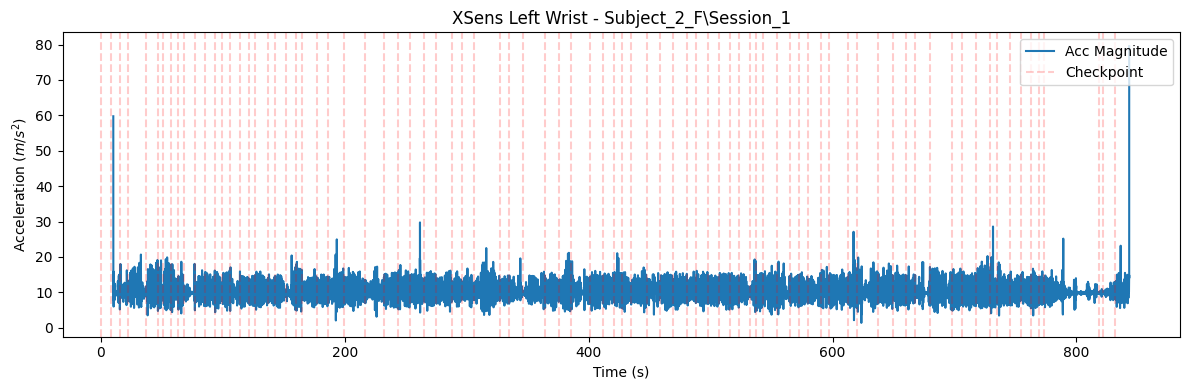

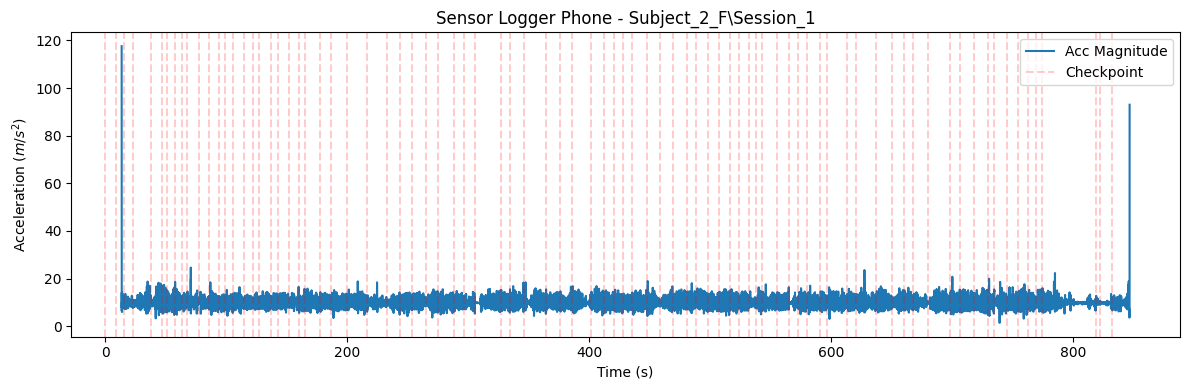

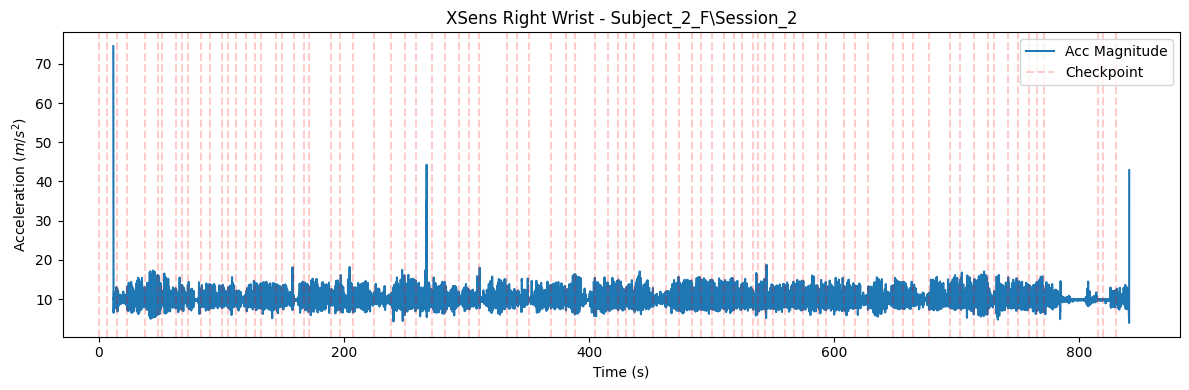

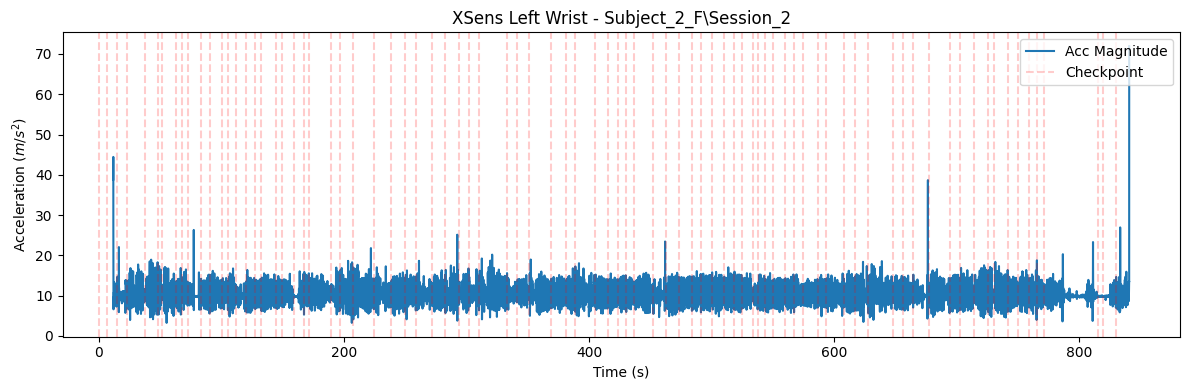

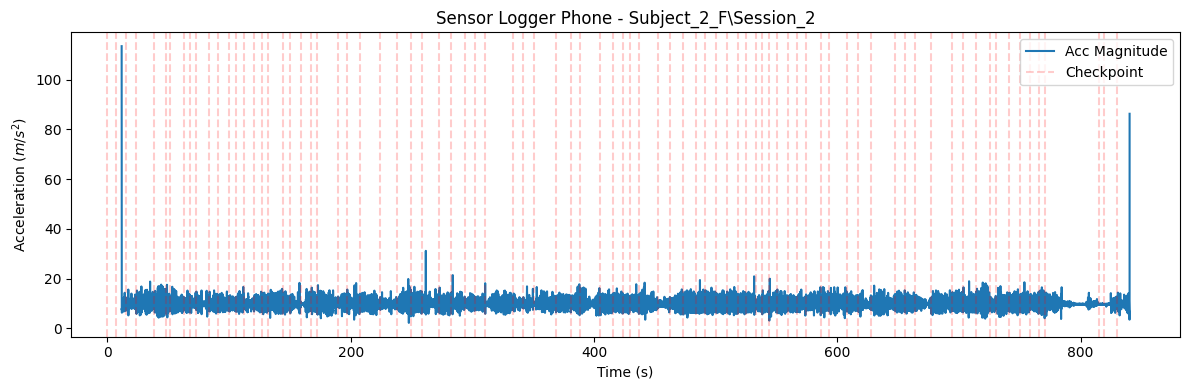

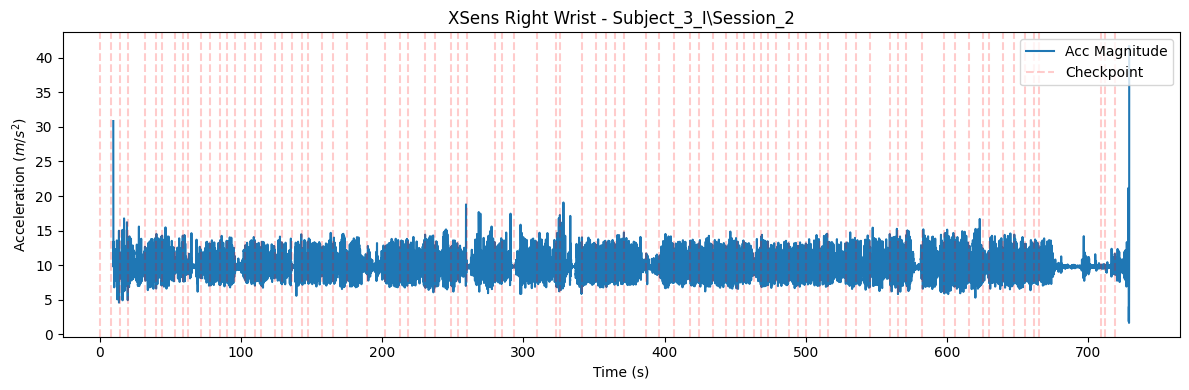

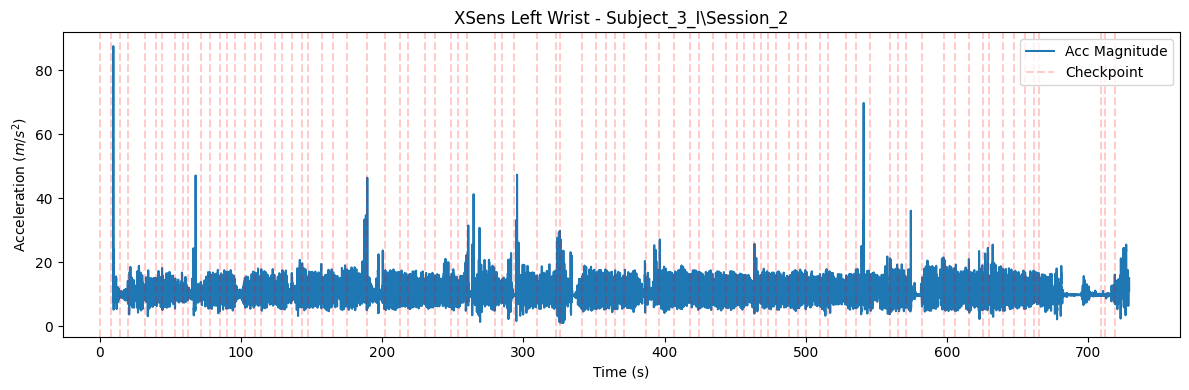

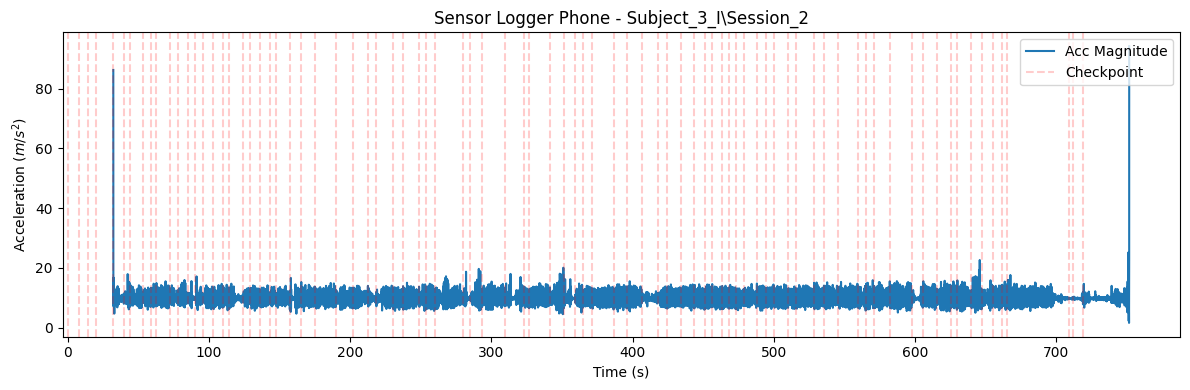

In [21]:
dir_file = [os.path.join("Subject_1_D", "Session_1"), os.path.join("Subject_1_D", "Session_2"), os.path.join("Subject_2_F", "Session_1"), os.path.join("Subject_2_F", "Session_2"), os.path.join("Subject_3_I", "Session_2")]
data_doc_dir = Path(r"C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data")

sensor_trimmed_dir = "XSens_trimmed"

sensor_logger_recordings_trimmed_dir = os.path.join("Sensor_logger_recordings", "trimmed")

step_logger_dir = "Step_logger"

xsens_file_prefix_right_wrist = "trimmed_10B41710"
xsens_file_prefix_left_wrist = "trimmed_10B4170C"

step_logger_file_prefix = "buttonsPressed"

sensor_logger_file_prefix = "trimmed_TotalAcceleration"

def plot_acceleration_magnitude_with_checkpoints(dir_file, data_doc_dir, sensor_trimmed_dir, sensor_logger_recordings_trimmed_dir, step_logger_dir, xsens_file_prefix_right_wrist, xsens_file_prefix_left_wrist, step_logger_file_prefix, sensor_logger_file_prefix):
    for i in range(len(dir_file)):
        # Load the Xsens trimmed data for right and left wrist
        right_wrist_path = os.path.join(data_doc_dir, dir_file[i], sensor_trimmed_dir, f"{xsens_file_prefix_right_wrist}.csv")
        left_wrist_path = os.path.join(data_doc_dir, dir_file[i], sensor_trimmed_dir, f"{xsens_file_prefix_left_wrist}.csv")
        
        right_wrist_df = pd.read_csv(right_wrist_path, delimiter=',', header=0)
        left_wrist_df = pd.read_csv(left_wrist_path, delimiter=',', header=0)
        
        # Load the Step Logger data
        step_logger_path = os.path.join(data_doc_dir, dir_file[i], step_logger_dir, f"{step_logger_file_prefix}.csv")
        step_logger_df = pd.read_csv(step_logger_path, delimiter=',', header=0)
        
        # Load the Sensor Logger data
        sensor_logger_path = os.path.join(data_doc_dir, dir_file[i], sensor_logger_recordings_trimmed_dir, f"{sensor_logger_file_prefix}.csv")
        sensor_logger_df = pd.read_csv(sensor_logger_path, delimiter=',', header=0)

        # Calculate the acceleration magnitude
        acc_mag_right_wrist = np.sqrt(right_wrist_df["Acc_X"]**2 + right_wrist_df["Acc_Y"]**2 + right_wrist_df["Acc_Z"]**2)
        acc_mag_left_wrist = np.sqrt(left_wrist_df["Acc_X"]**2 + left_wrist_df["Acc_Y"]**2 + left_wrist_df["Acc_Z"]**2)

        acc_mag_sensor_logger = np.sqrt(sensor_logger_df["x"]**2 + sensor_logger_df["y"]**2 + sensor_logger_df["z"]**2)

        plots_data = [
            ("XSens Right Wrist", right_wrist_df["Time_s"], acc_mag_right_wrist),
            ("XSens Left Wrist", left_wrist_df["Time_s"], acc_mag_left_wrist),
            ("Sensor Logger Phone", sensor_logger_df["time_s"], acc_mag_sensor_logger),
        ]

        # 4. Generate 3 Graphs per Session
        for title_prefix, time_col, mag_signal in plots_data:
            plt.figure(figsize=(12, 4))
            plt.ticklabel_format(useOffset=False, style="plain")

            # Plot Accelerometer Signal
            plt.plot(time_col, mag_signal, label="Acc Magnitude", color="C0")

            # Overlay Checkpoint Event Lines
            for idx, cp_time in enumerate(step_logger_df["time_s"]):
                # Add label only to the first line so the legend stays clean
                label = "Checkpoint" if idx == 0 else ""
                plt.axvline(
                    x=cp_time,
                    color="r",
                    linestyle="--",
                    alpha=0.2,
                    label=label,
                )

            plt.xlabel("Time (s)")
            plt.ylabel("Acceleration ($m/s^2$)")
            plt.title(f"{title_prefix} - {dir_file[i]}")
            plt.legend(loc="upper right")
            plt.tight_layout()
            plt.show()

plot_acceleration_magnitude_with_checkpoints(dir_file, data_doc_dir, sensor_trimmed_dir, sensor_logger_recordings_trimmed_dir, step_logger_dir, xsens_file_prefix_right_wrist, xsens_file_prefix_left_wrist, step_logger_file_prefix, sensor_logger_file_prefix)

Mapping the Timestamp in Xsens and Android Phone sensor recording and then mapping the events according to the step logger accurately

Davide Session 1 and 2

In [14]:
dir_file = [os.path.join("Subject_1_D", "Session_1"), os.path.join("Subject_1_D", "Session_2")] #os.path.join("Subject_2_F", "Session_1"), os.path.join("Subject_2_F", "Session_2"), os.path.join("Subject_3_I", "Session_2")]
data_doc_dir = Path(r"C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data")

sensor_trimmed_dir = "XSens_trimmed"

sensor_logger_recordings_trimmed_dir = os.path.join("Sensor_logger_recordings", "trimmed")

step_logger_dir = "Step_logger"

xsens_file_prefix_right_wrist = "trimmed_10B41710"
xsens_file_prefix_left_wrist = "trimmed_10B4170C"

step_logger_file_prefix = "buttonsPressed"

sensor_logger_file_prefix = "trimmed_TotalAcceleration"

def map_datapoints(dir_file, data_doc_dir, sensor_trimmed_dir, sensor_logger_recordings_trimmed_dir, step_logger_dir, xsens_file_prefix_right_wrist, xsens_file_prefix_left_wrist, step_logger_file_prefix, sensor_logger_file_prefix):
    for i in range(len(dir_file)):
        # Load the Xsens trimmed data for right and left wrist
        right_wrist_path = os.path.join(data_doc_dir, dir_file[i], sensor_trimmed_dir, f"{xsens_file_prefix_right_wrist}.csv")
        left_wrist_path = os.path.join(data_doc_dir, dir_file[i], sensor_trimmed_dir, f"{xsens_file_prefix_left_wrist}.csv")
        
        right_wrist_df = pd.read_csv(right_wrist_path, delimiter=',', header=0)
        left_wrist_df = pd.read_csv(left_wrist_path, delimiter=',', header=0)
        
        # Load the Step Logger data
        step_logger_path = os.path.join(data_doc_dir, dir_file[i], step_logger_dir, f"{step_logger_file_prefix}.csv")
        step_logger_df = pd.read_csv(step_logger_path, delimiter=',', header=0)
        
        # Load the Sensor Logger data
        sensor_logger_path = os.path.join(data_doc_dir, dir_file[i], sensor_logger_recordings_trimmed_dir, f"{sensor_logger_file_prefix}.csv")
        sensor_logger_df = pd.read_csv(sensor_logger_path, delimiter=',', header=0)

        total_samples = len(sensor_logger_df)

        duration_seconds = round((sensor_logger_df["time"].iloc[-1] - sensor_logger_df["time"].iloc[0]) / 1e9 ,4)

        sampling_rate = (total_samples -1) / duration_seconds

        print(f"Estimated Sampling Rate: {sampling_rate:.4f} Hz")

        acc_mag_right_wrist = np.sqrt(right_wrist_df["Acc_X"]**2 + right_wrist_df["Acc_Y"]**2 + right_wrist_df["Acc_Z"]**2)
        acc_mag_left_wrist = np.sqrt(left_wrist_df["Acc_X"]**2 + left_wrist_df["Acc_Y"]**2 + left_wrist_df["Acc_Z"]**2)
        acc_mag_sensor_logger = np.sqrt(sensor_logger_df["x"]**2 + sensor_logger_df["y"]**2 + sensor_logger_df["z"]**2)

        acc_mag_df = pd.DataFrame()
        acc_mag_df["Acc_mag_phone_logger"] = acc_mag_sensor_logger
        acc_mag_df["Acc_mag_left_wrist"] = acc_mag_left_wrist
        acc_mag_df["Acc_mag_right_sensor"] = acc_mag_right_wrist



        print(acc_mag_df.head(10))



map_datapoints(dir_file, data_doc_dir, sensor_trimmed_dir, sensor_logger_recordings_trimmed_dir, step_logger_dir, xsens_file_prefix_right_wrist, xsens_file_prefix_left_wrist, step_logger_file_prefix, sensor_logger_file_prefix)

Estimated Sampling Rate: 100.3447 Hz
   Acc_mag_phone_logger  Acc_mag_left_wrist  Acc_mag_right_sensor
0             89.027708           40.617852             47.308380
1             49.797129           68.306877             35.878649
2             43.713071           46.383194             38.172003
3             39.530181           19.536033             11.070918
4             36.797419           19.204558             10.506240
5             18.764059           17.930217             17.216379
6             10.921496           15.114480             15.517034
7             12.883045           11.327580             11.656744
8             12.361229            7.758239              7.948221
9              8.792919            5.378047              7.843593
Estimated Sampling Rate: 100.4677 Hz
   Acc_mag_phone_logger  Acc_mag_left_wrist  Acc_mag_right_sensor
0            145.275904          122.615534             50.069236
1            116.375814          102.415213             34.824960
2 

Converting the trimmed data to 60 Hz so that we can map it directly to the XSens data.

In [19]:
def downsample_with_nanos(df: pd.DataFrame, time_col: str, signal_cols: list, orig_fs=100, target_fs=60) -> pd.DataFrame:
    """Downsamples signal columns and constructs matching nanosecond timestamps."""
    # 1. Compute anti-aliased polyphase resampling ratio (3/5 for 100Hz -> 60Hz)
    up = 3
    down = 5

    # 2. Resample signal columns
    resampled_data = {}
    for col in signal_cols:
        resampled_data[col] = resample_poly(df[col].values, up, down)

    num_samples = len(next(iter(resampled_data.values())))

    # 3. Reconstruct absolute nanosecond timestamps from original t0
    t0_nano = df[time_col].iloc[0]

    # Calculate step size in nanoseconds (1e9 ns / 60 Hz = 16_666_666.67 ns)
    ns_per_sample = 1e9 / target_fs

    # Create uniform nanosecond array starting at exact original baseline
    new_nanos = (
        t0_nano + np.arange(num_samples) * ns_per_sample).astype(np.int64)

    # 4. Construct downsampled DataFrame
    out_df = pd.DataFrame(resampled_data)
    out_df[time_col] = new_nanos

    out_df["Time_s"] = ((out_df[time_col] - t0_nano) / 1e9).round(6)

    return out_df

data_doc_dir = Path(r"C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data")
dir_file = [os.path.join("Subject_1_D", "Session_1"), os.path.join("Subject_1_D", "Session_2"), os.path.join("Subject_2_F", "Session_1"), os.path.join("Subject_2_F", "Session_2"), os.path.join("Subject_3_I", "Session_2")]

sensor_logger_recordings_trimmed_dir = os.path.join("Sensor_logger_recordings", "trimmed")

sensor_logger_file_prefix = "trimmed_TotalAcceleration"

for i in range(len(dir_file)):

    # Load the Sensor Logger data
    sensor_logger_path = os.path.join(data_doc_dir, dir_file[i], sensor_logger_recordings_trimmed_dir, f"{sensor_logger_file_prefix}.csv")
    sensor_logger_df = pd.read_csv(sensor_logger_path, delimiter=',', header=0)

    resampled_df = downsample_with_nanos(sensor_logger_df, time_col="time", signal_cols=["z", "y", "x"])

    OUT_DIR = Path(os.path.join(data_doc_dir, dir_file[i], "Sensor_logger_recordings", "trimmed_60Hz"))
    OUT_DIR.mkdir(exist_ok=True)

    sensor_logger_df.to_csv(OUT_DIR / f"{sensor_logger_file_prefix}.csv", index=False)

    print(f"Saved {len(sensor_logger_df)} trimmed files to {OUT_DIR}")

Saved 76674 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_1\Sensor_logger_recordings\trimmed_60Hz
Saved 77579 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_1_D\Session_2\Sensor_logger_recordings\trimmed_60Hz
Saved 83682 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_2_F\Session_1\Sensor_logger_recordings\trimmed_60Hz
Saved 83117 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_2_F\Session_2\Sensor_logger_recordings\trimmed_60Hz
Saved 72260 trimmed files to C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data\Subject_3_I\Session_2\Sensor_logger_recordings\trimmed_60Hz


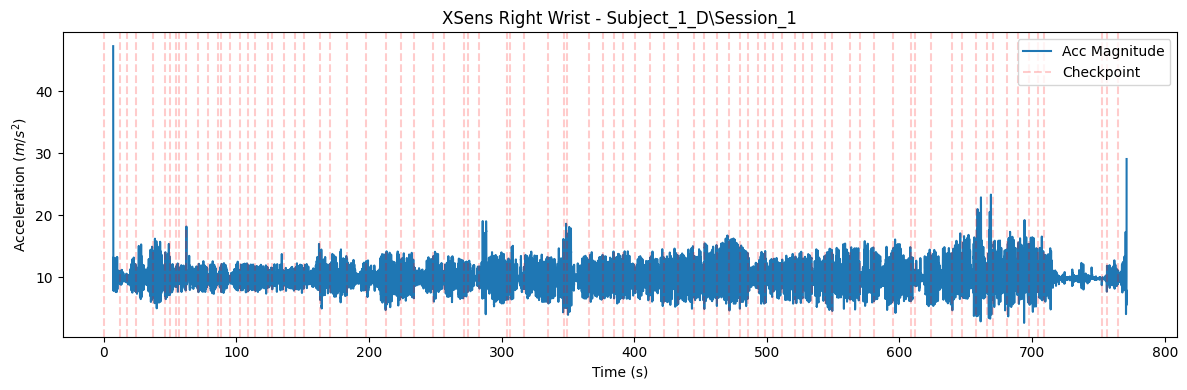

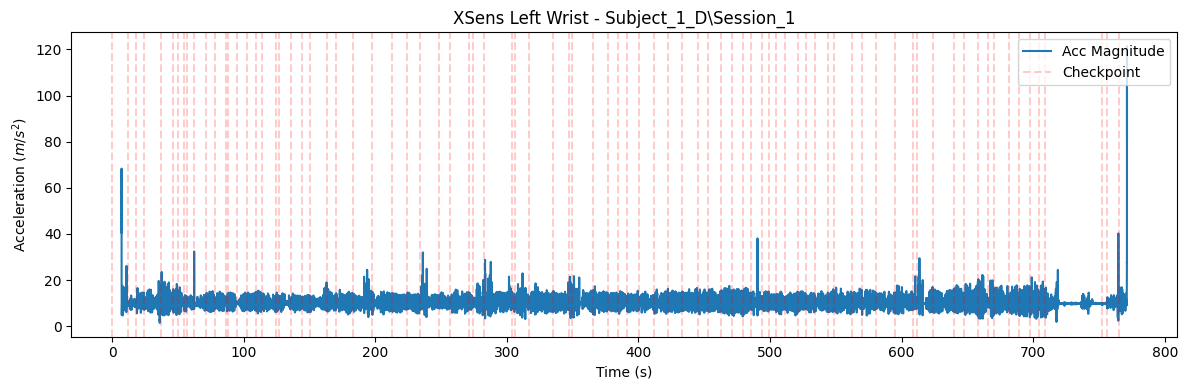

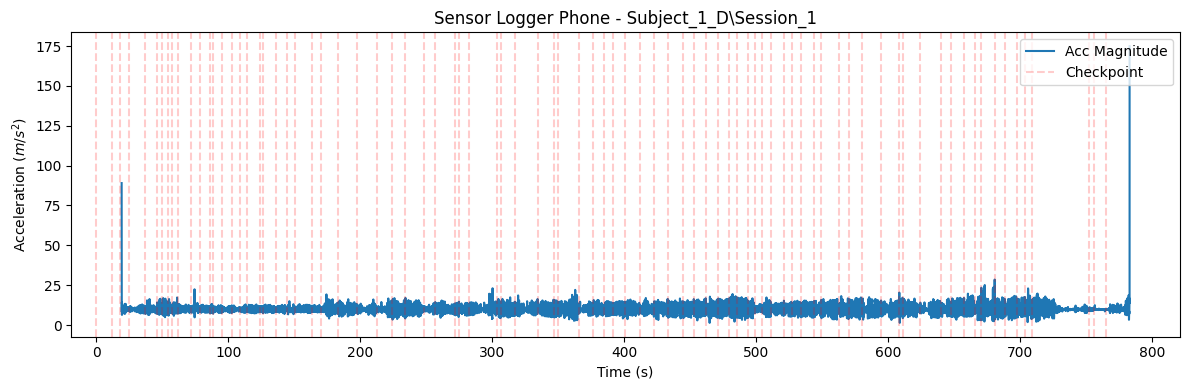

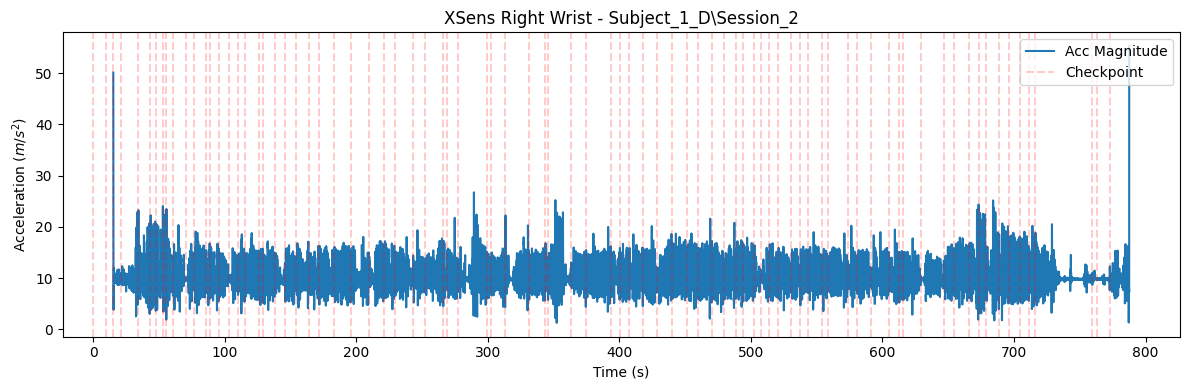

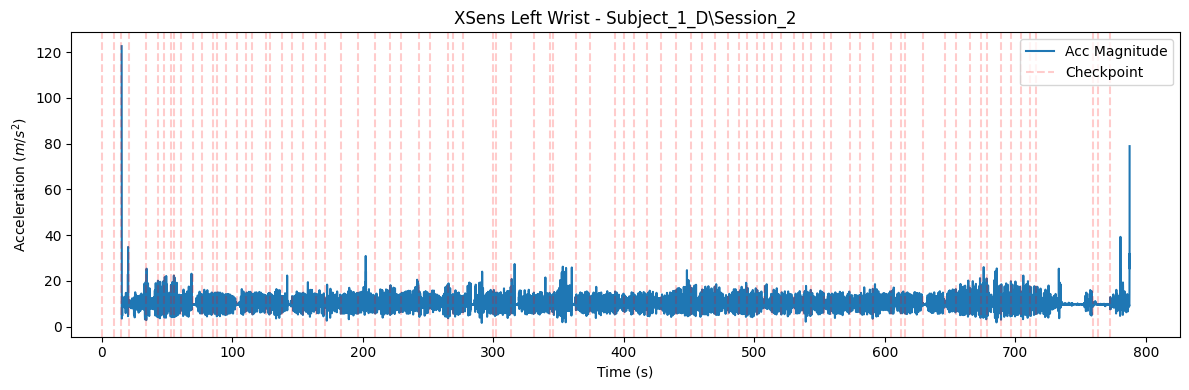

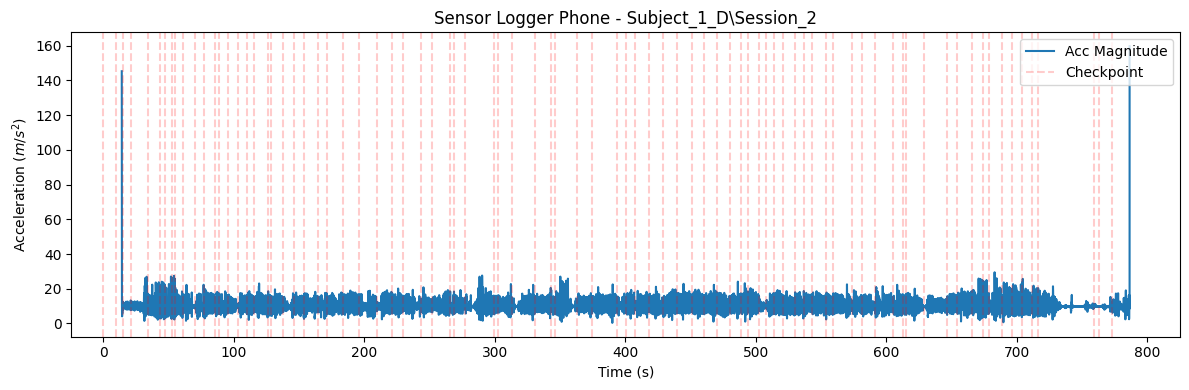

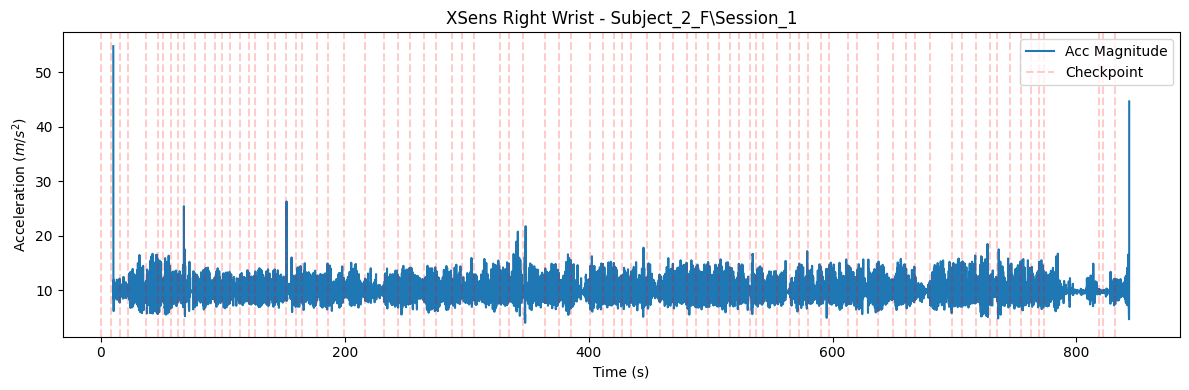

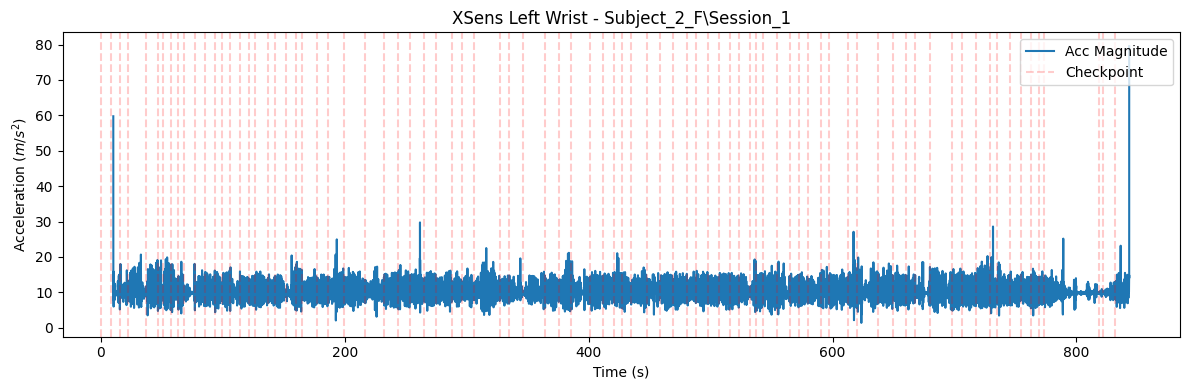

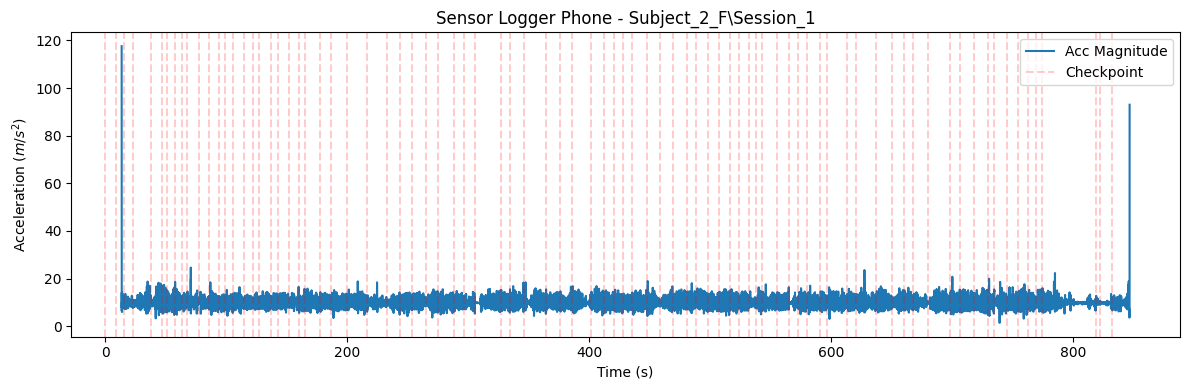

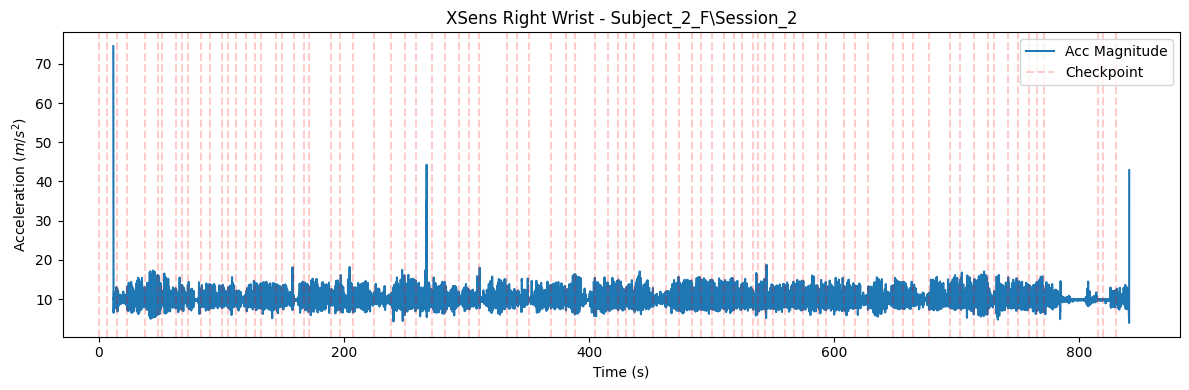

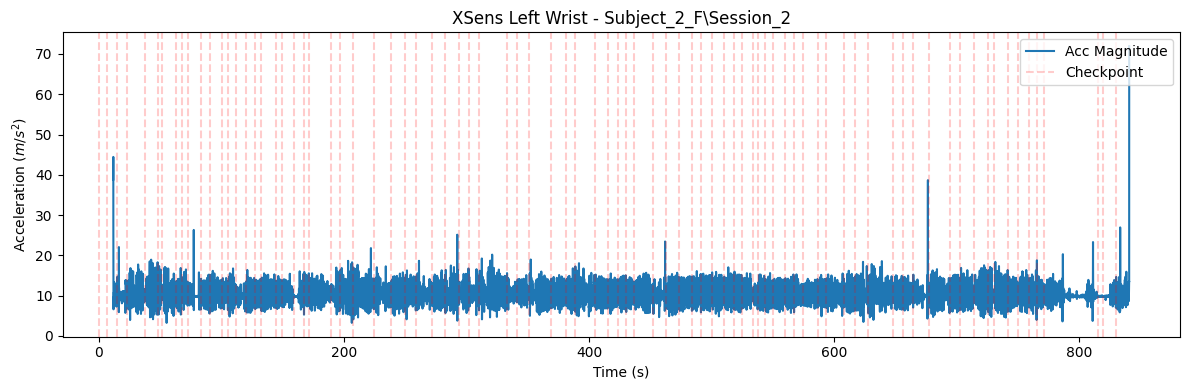

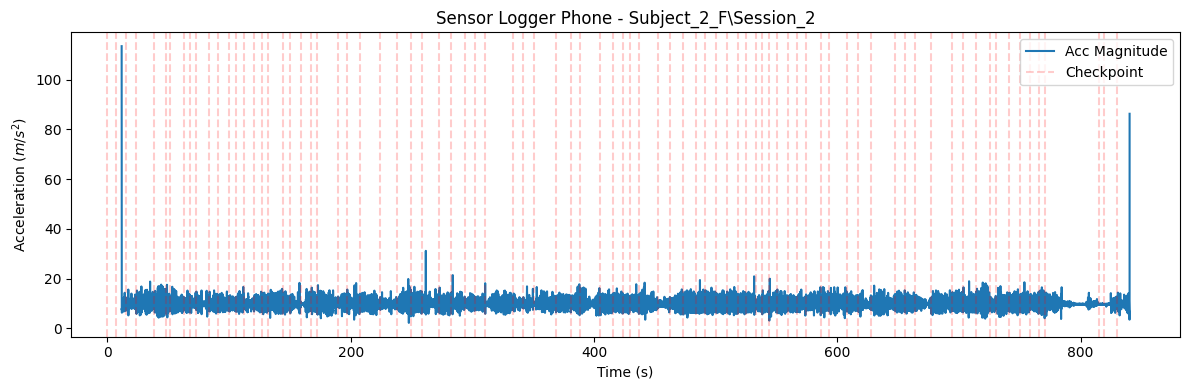

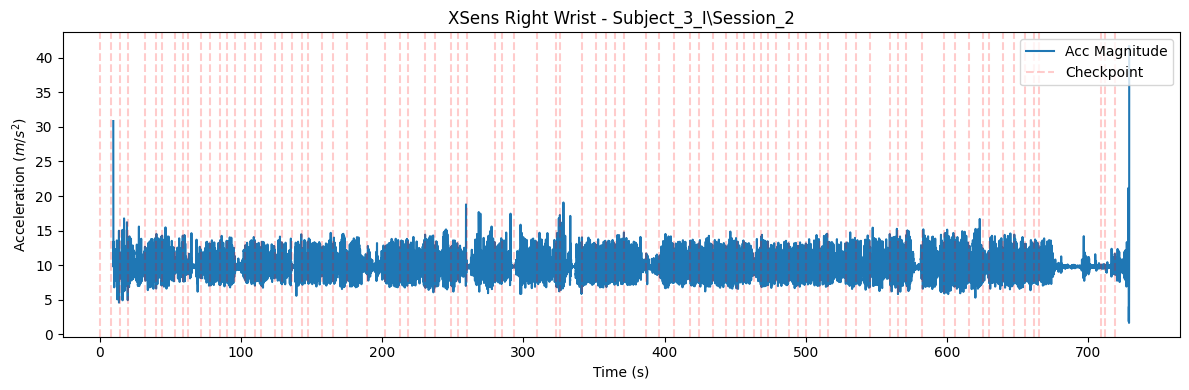

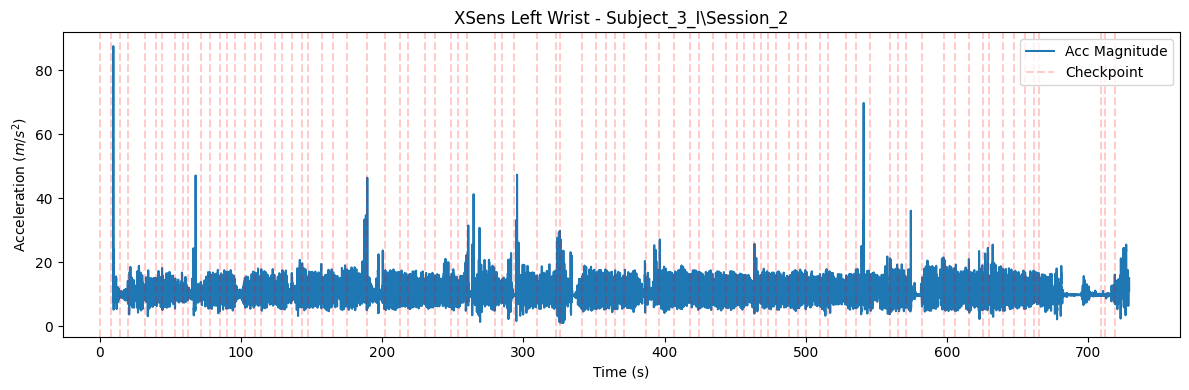

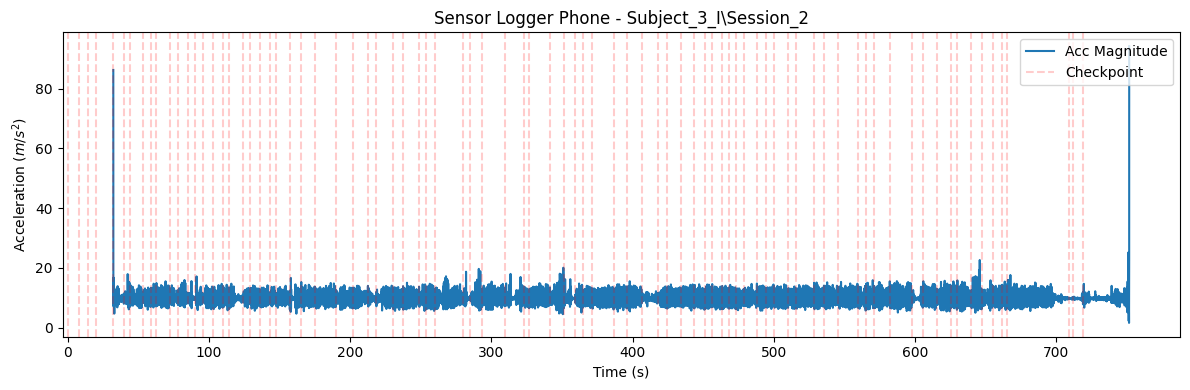

In [22]:
dir_file = [os.path.join("Subject_1_D", "Session_1"), os.path.join("Subject_1_D", "Session_2"), os.path.join("Subject_2_F", "Session_1"), os.path.join("Subject_2_F", "Session_2"), os.path.join("Subject_3_I", "Session_2")]
data_doc_dir = Path(r"C:\Users\Vaibhav\Documents\Data_Collection_Rome\Data")

sensor_trimmed_dir = "XSens_trimmed"

sensor_logger_recordings_trimmed_dir = os.path.join("Sensor_logger_recordings", "trimmed_60Hz")

step_logger_dir = "Step_logger"

xsens_file_prefix_right_wrist = "trimmed_10B41710"
xsens_file_prefix_left_wrist = "trimmed_10B4170C"

step_logger_file_prefix = "buttonsPressed"

sensor_logger_file_prefix = "trimmed_TotalAcceleration"

plot_acceleration_magnitude_with_checkpoints(dir_file, data_doc_dir, sensor_trimmed_dir, sensor_logger_recordings_trimmed_dir, step_logger_dir, xsens_file_prefix_right_wrist, xsens_file_prefix_left_wrist, step_logger_file_prefix, sensor_logger_file_prefix)

Detected 11 jump/checkpoint events:
    checkpoint_id  start_time    end_time  duration_s  peak_acc_z  \
0               1    8.966667   10.550000    1.583333   21.959555   
1               2   71.333333   71.650000    0.316667   24.141258   
2               3  131.000000  132.016667    1.016667   23.794402   
3               4  191.000000  192.233333    1.233333   22.420173   
4               5  251.750000  252.883333    1.133333   34.140020   
5               6  310.950000  312.350000    1.400000   21.129837   
6               7  370.816667  372.033333    1.216667   23.575276   
7               8  431.183333  432.600000    1.416667   20.374096   
8               9  490.866667  492.233333    1.366667   28.242813   
9              10  550.716667  552.133333    1.416667   23.955059   
10             11  567.383333  567.533333    0.150000   19.388205   

   start_timestamp end_timestamp  
0     00:00:08.966  00:00:10.550  
1     00:01:11.333  00:01:11.650  
2     00:02:11.000  00:02:12.0

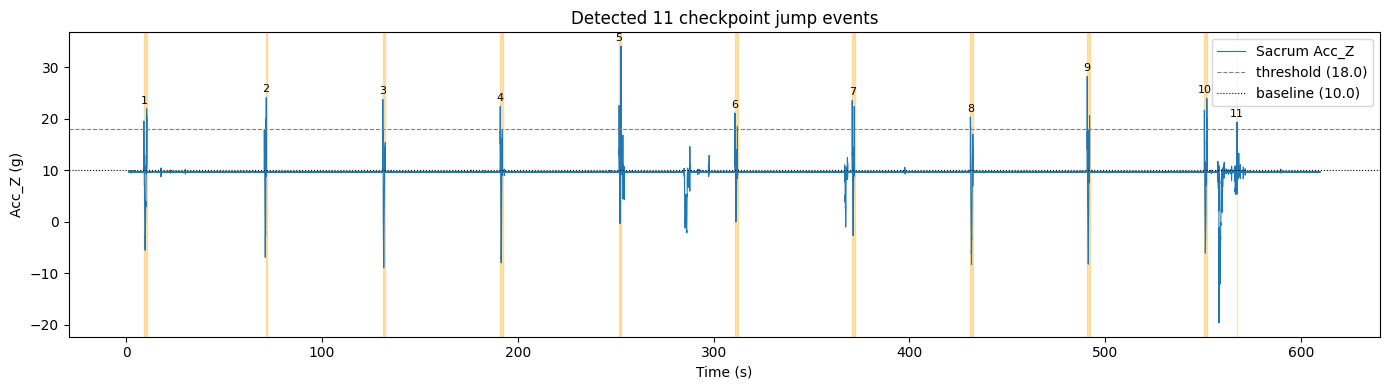

In [15]:
FS = 60  # Hz

TRIMMED_DIR = Path(r"C:\Users\Vaibhav\Documents\TemporaryDataCollection\trimmed")

JUMP_THRESH = 18.0       # Acc_Z above this = candidate jump/checkpoint event
BASELINE = 10.0          # standing baseline Acc_Z (approx gravity on local Z axis)
BASELINE_TOL = 2.0       # +/- band around baseline counted as "settled"
MIN_SETTLE_S = 0.15      # must stay within the band this long to count as truly settled

# %% [markdown]
# ## Load data
# Expects a trimmed_sacrum.csv with columns Time_s and Acc_Z (from Step 1).

# %%
sacrum = pd.read_csv(TRIMMED_DIR / "trimmed_10B41722.csv")
time_s = sacrum["Time_s"].values
acc_z = sacrum["Acc_Z"].values
timestamp = sacrum["Timestamp"].values

# %% [markdown]
# ## Detector

# %%
def detect_jump_events(time_s: np.ndarray, acc_z: np.ndarray, timestamp: np.ndarray,
                        thresh: float = JUMP_THRESH,
                        baseline: float = BASELINE,
                        tol: float = BASELINE_TOL,
                        min_settle_s: float = MIN_SETTLE_S,
                        fs: int = FS) -> pd.DataFrame:
    n = len(acc_z)
    min_settle_samples = max(1, int(round(min_settle_s * fs)))

    events = []
    i = 0
    while i < n:
        if acc_z[i] > thresh:
            start_idx = i

            # Scan forward until Acc_Z stays within [baseline-tol, baseline+tol]
            # for min_settle_samples in a row.
            j = i
            settled_idx = None
            while j < n:
                window_end = j + min_settle_samples
                if window_end > n:
                    settled_idx = n - 1  # ran out of data; close event at the end
                    break
                window = acc_z[j:window_end]
                if np.all(np.abs(window - baseline) <= tol):
                    settled_idx = window_end - 1
                    break
                j += 1
            if settled_idx is None:
                settled_idx = n - 1

            events.append({
                "start_time": time_s[start_idx],
                "end_time": time_s[settled_idx],
                "duration_s": time_s[settled_idx] - time_s[start_idx],
                "peak_acc_z": acc_z[start_idx:settled_idx + 1].max(),
                "start_timestamp": timestamp[start_idx],
                "end_timestamp": timestamp[settled_idx],
            })

            i = settled_idx + 1  # resume search after this event
        else:
            i += 1

    return pd.DataFrame(events)


jump_events = detect_jump_events(time_s, acc_z, timestamp)
jump_events.insert(0, "checkpoint_id", range(1, len(jump_events) + 1))
print(f"Detected {len(jump_events)} jump/checkpoint events:")
print(jump_events)

# %% [markdown]
# ## Plot detected events over the raw signal

# %%
plt.figure(figsize=(14, 4))
plt.plot(time_s, acc_z, label="Sacrum Acc_Z", linewidth=0.8)
plt.axhline(JUMP_THRESH, color="gray", linestyle="--", linewidth=0.8, label=f"threshold ({JUMP_THRESH})")
plt.axhline(BASELINE, color="black", linestyle=":", linewidth=0.8, label=f"baseline ({BASELINE})")

for _, row in jump_events.iterrows():
    plt.axvspan(row["start_time"], row["end_time"], color="orange", alpha=0.3)
    plt.text(row["start_time"], row["peak_acc_z"] + 1, str(int(row["checkpoint_id"])),
              fontsize=8, ha="center")

plt.xlabel("Time (s)")
plt.ylabel("Acc_Z (g)")
plt.title(f"Detected {len(jump_events)} checkpoint jump events")
plt.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Save checkpoint timestamps (for syncing against the other device's clock)

# %%
#OUT_DIR = TRIMMED_DIR.parent / "checkpoints"
#OUT_DIR.mkdir(exist_ok=True)
#jump_events.to_csv(OUT_DIR / "jump_checkpoints.csv", index=False)
#print(f"Saved checkpoint timestamps to {OUT_DIR / 'jump_checkpoints.csv'}")

Sacrum detected 2 turn segments
   start_time   end_time  duration_s direction
0   21.433333  44.016667   22.583333    CW (-)
1   49.466667  51.000000    1.533333    CW (-)

Head detected 8 turn segments
   start_time   end_time  duration_s direction
0   14.550000  14.966667    0.416667    CW (-)
1   17.833333  18.366667    0.533333    CW (-)
2   20.333333  21.116667    0.783333   CCW (+)
3   23.416667  25.900000    2.483333    CW (-)
4   28.983333  32.066667    3.083333    CW (-)
5   34.400000  38.500000    4.100000    CW (-)
6   40.150000  43.216667    3.066667    CW (-)
7   49.116667  49.833333    0.716667    CW (-)

Sacrum turns with cross-validation:
   start_time   end_time  duration_s direction  confirmed_by_other_sensor
0   21.433333  44.016667   22.583333    CW (-)                       True
1   49.466667  51.000000    1.533333    CW (-)                       True

2/2 sacrum-detected turns confirmed by head sensor


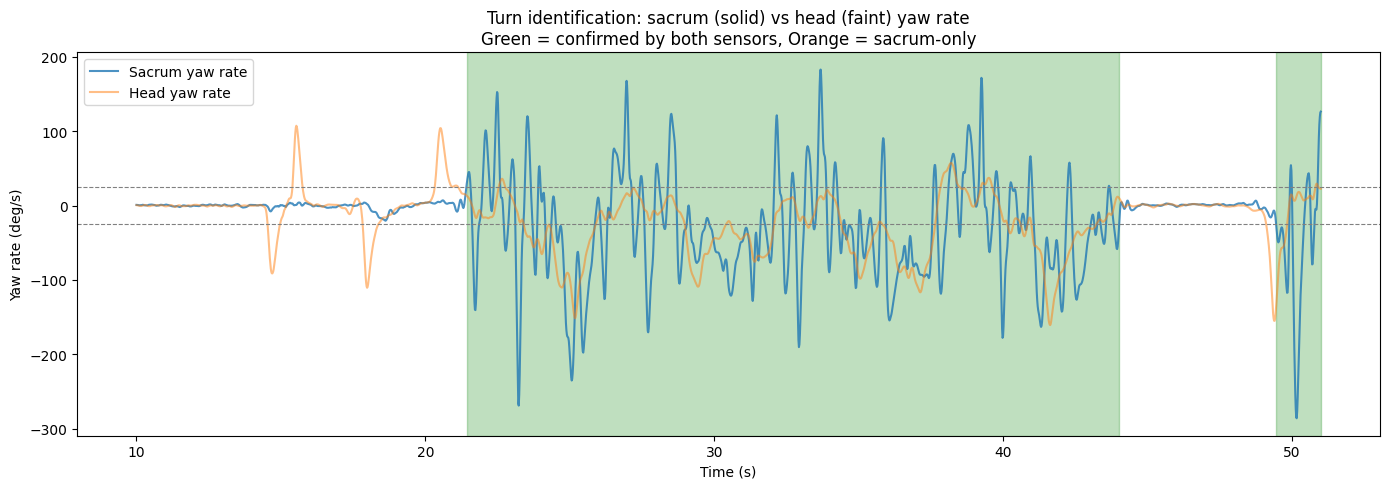

Saved turn segments to C:\Users\Vaibhav\Documents\MT_Data_Collection_Session1\Recording7_T_Pose_Walk_01_diff_track\turns\turn_segments.csv


In [ ]:
FS = 60  # Hz

TRIMMED_DIR = Path(r"C:\Users\Vaibhav\Documents\MT_Data_Collection_Session1\Recording7_T_Pose_Walk_01_diff_track\trimmed")  # folder with trimmed_*.csv from Step 1

# Turn-detection tuning
YAW_RATE_THRESH_DEG_S = 25.0   # yaw rate above this = candidate turning
MIN_TURN_DURATION_S = 0.4      # ignore blips shorter than this
MAX_GAP_TO_MERGE_S = 0.3       # merge two turn segments if the gap between them is smaller than this
SMOOTH_WINDOW_SAMPLES = 7      # moving-average window for yaw rate (must be odd-ish, small)

# %% [markdown]
# ## Load trimmed sacrum + head signals (output of Step 1)

# %%
sacrum = pd.read_csv(TRIMMED_DIR / "trimmed_sacrum.csv")
head = pd.read_csv(TRIMMED_DIR / "trimmed_head.csv")

assert len(sacrum) == len(head), "Sacrum and head signals must be the same length/time-aligned"

# %% [markdown]
# ## Compute smoothed yaw rate (deg/s) for a sensor
#
# 1. Unwrap Yaw to remove the +/-180 deg wraparound discontinuity.
# 2. Differentiate w.r.t. time to get yaw rate.
# 3. Light moving-average smoothing to suppress gait-sway jitter without
#    blurring out real turns (turns last much longer than a stride).


# %%
def compute_yaw_rate(df: pd.DataFrame, smooth_window: int = SMOOTH_WINDOW_SAMPLES) -> np.ndarray:
    yaw_unwrapped_deg = np.rad2deg(np.unwrap(np.deg2rad(df["Yaw"].values)))
    yaw_rate = np.gradient(yaw_unwrapped_deg, df["Time_s"].values)
    yaw_rate_smooth = pd.Series(yaw_rate).rolling(
        window=smooth_window, center=True, min_periods=1
    ).mean().values
    return yaw_rate_smooth


sacrum["YawRate"] = compute_yaw_rate(sacrum)
head["YawRate"] = compute_yaw_rate(head)

# %% [markdown]
# ## Turn segment extraction from a yaw-rate signal
#
# Threshold -> boolean mask -> merge nearby True runs -> drop runs shorter
# than MIN_TURN_DURATION_S -> return list of (start_time, end_time, direction).
# direction: +1 = turning one way (e.g. left/CCW), -1 = the other way, based
# on the sign of yaw rate during the segment.


# %%
def extract_turn_segments(time_s: np.ndarray, yaw_rate: np.ndarray,
                           thresh: float = YAW_RATE_THRESH_DEG_S,
                           min_duration: float = MIN_TURN_DURATION_S,
                           max_gap: float = MAX_GAP_TO_MERGE_S) -> pd.DataFrame:
    is_turning = np.abs(yaw_rate) > thresh

    # Find raw True runs
    segments = []
    in_run = False
    start_idx = None
    for i, flag in enumerate(is_turning):
        if flag and not in_run:
            in_run = True
            start_idx = i
        elif not flag and in_run:
            in_run = False
            segments.append((start_idx, i - 1))
    if in_run:
        segments.append((start_idx, len(is_turning) - 1))

    if not segments:
        return pd.DataFrame(columns=["start_time", "end_time", "duration_s", "direction"])

    # Merge segments separated by a small gap
    merged = [list(segments[0])]
    for s, e in segments[1:]:
        gap = time_s[s] - time_s[merged[-1][1]]
        if gap <= max_gap:
            merged[-1][1] = e
        else:
            merged.append([s, e])

    # Filter by minimum duration, compute direction (sign of mean yaw rate in segment)
    rows = []
    for s, e in merged:
        duration = time_s[e] - time_s[s]
        if duration >= min_duration:
            direction = np.sign(np.mean(yaw_rate[s:e + 1]))
            rows.append({
                "start_time": time_s[s],
                "end_time": time_s[e],
                "duration_s": duration,
                "direction": "CCW (+)" if direction > 0 else "CW (-)",
            })

    return pd.DataFrame(rows)


sacrum_turns = extract_turn_segments(sacrum["Time_s"].values, sacrum["YawRate"].values)
head_turns = extract_turn_segments(head["Time_s"].values, head["YawRate"].values)

print(f"Sacrum detected {len(sacrum_turns)} turn segments")
print(sacrum_turns)
print(f"\nHead detected {len(head_turns)} turn segments")
print(head_turns)

# %% [markdown]
# ## Cross-validate sacrum vs head
#
# Two independent sensors agreeing on a turn window gives high confidence.
# A turn segment is "confirmed" if a head-sensor segment overlaps it in time.


# %%
def cross_validate(turns_a: pd.DataFrame, turns_b: pd.DataFrame) -> pd.DataFrame:
    confirmed = []
    for _, row in turns_a.iterrows():
        overlap = turns_b[
            (turns_b["start_time"] <= row["end_time"]) &
            (turns_b["end_time"] >= row["start_time"])
        ]
        confirmed.append(len(overlap) > 0)
    result = turns_a.copy()
    result["confirmed_by_other_sensor"] = confirmed
    return result


sacrum_turns_validated = cross_validate(sacrum_turns, head_turns)
print("\nSacrum turns with cross-validation:")
print(sacrum_turns_validated)

n_confirmed = sacrum_turns_validated["confirmed_by_other_sensor"].sum()
print(f"\n{n_confirmed}/{len(sacrum_turns_validated)} sacrum-detected turns confirmed by head sensor")

# %% [markdown]
# ## Plot: yaw rate + detected turn windows (sacrum, with head overlay)

# %%
plt.figure(figsize=(14, 5))
plt.plot(sacrum["Time_s"], sacrum["YawRate"], label="Sacrum yaw rate", alpha=0.8)
plt.plot(head["Time_s"], head["YawRate"], label="Head yaw rate", alpha=0.5)
plt.axhline(YAW_RATE_THRESH_DEG_S, color="gray", linestyle="--", linewidth=0.8)
plt.axhline(-YAW_RATE_THRESH_DEG_S, color="gray", linestyle="--", linewidth=0.8)

for _, row in sacrum_turns_validated.iterrows():
    color = "green" if row["confirmed_by_other_sensor"] else "orange"
    plt.axvspan(row["start_time"], row["end_time"], color=color, alpha=0.25)

plt.xlabel("Time (s)")
plt.ylabel("Yaw rate (deg/s)")
plt.title("Turn identification: sacrum (solid) vs head (faint) yaw rate\n"
          "Green = confirmed by both sensors, Orange = sacrum-only")
plt.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Save turn segments (feeds Step 3: Signals Segmentation)

# %%
OUT_DIR = TRIMMED_DIR.parent / "turns"
OUT_DIR.mkdir(exist_ok=True)
sacrum_turns_validated.to_csv(OUT_DIR / "turn_segments.csv", index=False)
print(f"Saved turn segments to {OUT_DIR / 'turn_segments.csv'}")